# FABN Portfolio Optimizer — SAP Statutory Objective  *(Phase 1, single-period)*

Under **Statutory Accounting Principles (SAP)**, bonds are held at **amortized cost** — value is created through **book-yield earnings per unit of required capital**, not market appreciation.

$$
\max_{h,v}\;\Big(
\underbrace{\sum_i (y_i - r^{FABN})\,h_i}_{\text{Bond NII}}
+\underbrace{r_{save}\,\Delta t\sum_q B_q}_{\text{Facility income}}
+\underbrace{\sum_k(c_k - r^{float})\,v_k}_{\text{Swap NII}}
-\underbrace{\lambda\sum_i\theta_i\,h_i}_{\text{Bond capital}}
-\underbrace{\lambda\mu\sum_k v_k}_{\text{Swap capital}}
-\underbrace{\eta\sum_q DF_q\, s^{net}_q}_{\text{Liquidity penalty}}
-\underbrace{\sum_i\tau_i(tc^+_i + tc^-_i)}_{\text{Turnover}}
\Big)
$$

| Term | Formula | Description |
|---|---|---|
| Bond NII | $\sum_i(y_i - r^{FABN})\,h_i$ | Book yield (coupon + amortization) net of FABN funding rate |
| Facility income | $r_{save}\,\Delta t\sum_q B_q$ | Reinvestment income earned on lending-facility surplus each quarter |
| Swap NII | $\sum_k(c_k - r^{float})\,v_k$ | Receive-fixed net income; positive when fixed rate $c_k >$ SOFR |
| Bond capital cost | $\lambda_{cap}\sum_i\theta_i h_i$ | C-1 RBC charge on bonds; $\lambda_{cap}$ = cost\_of\_capital × RBC\_bar |
| Swap capital cost | $\lambda_{cap}\,\mu\sum_k v_k$ | C-3 RBC charge on swap notional |
| Liquidity penalty | $\eta\sum_q DF_q\, s^{net}_q$ | PV of quarterly cash shortfalls in the lending facility |
| Turnover cost | $\sum_i\tau_i(tc^+_i + tc^-_i)$ | Actual bid-ask half-spread on buys ($tc^+$) and sells ($tc^-$) |

**Constraints:** budget $\sum h_i = H$; duration band $\bigl|\sum D_i h_i + \sum D^{sw}_k v_k - D^{FABN}H\bigr|\le\varepsilon_D H$; issuer cap $\le 5\%\cdot H$; quarterly facility balance recursion; CVaR tail-loss limit $\le\phi_{cvar}H$; swap notional cap $\sum v_k \le 20\%\cdot H$.

**Run order:** `Date Selection → 0 → 1A → 1B → 2 → 3 → 3B → 3B-ii → 3C → 4`

## Changes vs `FABN_Optimizer_SAP_Shadow.ipynb` (backup — no swaps)

| Addition | Detail |
|---|---|
| Swap variables $v_k \ge 0$ | Notional ($) for each receive-fixed tenor: 1yr, 2yr, 3yr |
| Swap NII in objective | $+\sum_k(c_k - r^{float})\,v_k$ — positive income when fixed rate exceeds SOFR |
| Swap capital cost in objective | $-\lambda\mu\sum_k v_k$ — C-3 RBC charge on swap notional |
| Duration constraint updated | $+\sum_k D^{sw}_k v_k$ — positive duration contribution from receive-fixed swaps |
| Facility constraints updated | $+\sum_k CF^{sw}_{q,k}\,v_k$ per quarter — net swap settlements enter the cash-flow balance |
| Swap notional cap (new) | Hard constraint: $\sum v_k \le 20\%\cdot H$ |
| Section 3C (new) | Duration attribution bonds vs swaps, notional by tenor, quarterly cash flows |

---
## Section 0 — Pipeline Run & Imports

In [31]:
# =============================================================================
# DATE SELECTION  --  change this date, then re-run all cells top-to-bottom
# =============================================================================
import pandas as pd   # available before %run

optimization_date = pd.Timestamp("2025-01-15")   # <- CHANGE THIS DATE

_FABN_ISSUE    = pd.Timestamp("2022-09-06")
_FABN_MATURITY = pd.Timestamp("2027-09-06")
assert optimization_date <= pd.Timestamp.today(), "Date is in the future -- no market data."
assert optimization_date > _FABN_ISSUE,  f"Date must be after FABN issue ({_FABN_ISSUE.date()})."
assert optimization_date < _FABN_MATURITY, f"Date must be before FABN maturity ({_FABN_MATURITY.date()})."
print(f"Optimization date selected : {optimization_date.date()}")

Optimization date selected : 2025-01-15


In [32]:
# Runs the data pipeline -- bond universe, FABN schedule, cash flows, durations,
# C-1 charges, spreads, prices, book yields, amortization, bid-ask tau -> `pipeline`.
%run FABN_Data_Pipeline_SAP_SWAP.ipynb

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
# numpy and pandas are already imported by the pipeline

Connected: insurance-backed-securities
Optimization date  : 2025-01-15
FABN issue/maturity: 2022-09-06 → 2027-09-06
Budget H           : $500,000,000
r_FABN             : 3.205%


c:\Users\lalot\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Universe size N = 303 bonds


c:\Users\lalot\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Spread coverage : 301/303 bonds  (2 missing)
Spread range    : -1.6 – 153.7 bps
Cashflow rows loaded : 2,517
Date range           : 2025-01-16 → 2033-02-15
bond_cf shape : (850, 303)  (T=850 payment dates × N=303 bonds)
qtr_bond_cf shape : (33, 303)  (Q=33 quarters × N=303 bonds)
Quarter range     : 2025Q1 → 2033Q1
Treasury curve date used : 2025-01-15  (FRED, attempt 1)
0.083yr     4.40
0.250yr     4.35
0.500yr     4.26
1.000yr     4.19
2.000yr     4.27
3.000yr     4.34
5.000yr     4.45
7.000yr     4.55
10.000yr    4.66
20.000yr    4.95
30.000yr    4.88

Duration computed from cashflows : 303
Duration from BBG fallback       : 0
Duration range                   : 1.16 – 6.40 yrs
Mean bond yield used             : 4.948%
theta range : 0.00158 – 0.02168
Mean C1     : 0.00911  (0.911%)
Rating source : 303 S&P, 0 Moody's fallback, 0 BBB default
h_curr (equal-weight) : $1,650,165.02 per bond
Full FABN schedule (per 100 face):
      date  coupon  principal    total
2023-03-06  1.6025       

c:\Users\lalot\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Mid price coverage : 301/303 bonds  (2 filled at par)
Book yield IRR     : 303/303 solved  (0 fell back to rf+spread)
Bid-ask tau        : 299/303 from quotes  (4 median-filled)
Book yield         : 4.54% – 6.82%  (mean 5.44%)
Coupon yield mean  : 4.28%   Amort yield mean : +1.159%
Bid-ask tau        : 1.1 – 29.7 bps  (mean 5.9 bps)
CVaR shock history: 375 days DGS5+IG-OAS (FRED, attempt 1)
CVaR scenarios: S=250 | rate shock std 31bp | spread shock std 7bp
Portfolio-avg loss: worst-5% mean ~ +1.50% of book | median -0.03%


,Metric,Value,Notes
0,Universe size (N),303,
1,Payment dates (T),850,
2,Quarterly periods (Q),33,
3,Spread mean (bps),59.4,
4,Book yield mean (%),5.44,
5,Bid-ask tau mean (bps),5.9,
6,Duration mean (yrs),2.97,
7,C1 charge mean (%),0.911,
8,FABN D target (yrs),2.489641,
9,Budget H ($M),500.0,



pipeline dict ready.


---
## Section 1 — Data & Parameters

In [33]:
# =============================================================================
# 1A. UNPACK PIPELINE  --  always run
# =============================================================================
N           = pipeline["N"]
Q           = pipeline["Q"]
CUSIPS      = pipeline["CUSIPS"]

book_yield  = pipeline["book_yield"]    # y_i = coupon_inc + amort_inc (effective-interest)
coupon_inc  = pipeline["coupon_inc"]    # statutory C_i (current coupon yield, per $)
amort_inc   = pipeline["amort_inc"]     # statutory A_i (amortization/accretion yield, per $)
spread      = pipeline["spread"]        # OAS spread (kept for reporting / comparison)
durs        = pipeline["durs"]          # modified duration (years)
theta       = pipeline["theta"]         # RBC factor f_i (C-1)
tau         = pipeline["tau"]           # bid-ask half-spread transaction cost (decimal)
price       = pipeline["price"]         # mid price per 100 face (book value)
h_curr      = pipeline["h_curr"]        # current allocation ($)

qtr_bond_cf = pipeline["qtr_bond_cf"]   # (Q, N) asset cash flows
qtr_fabn_cf = pipeline["qtr_fabn_cf"]   # (Q,)  FABN liability cash flows
qtr_idx     = pipeline["qtr_idx"]

# Truncate quarterly grid to FABN maturity horizon
_fabn_qtr   = pd.Period(_FABN_MATURITY, freq="Q")
_keep       = qtr_idx <= _fabn_qtr
qtr_bond_cf = qtr_bond_cf[_keep]
qtr_fabn_cf = qtr_fabn_cf[_keep]
qtr_idx     = qtr_idx[_keep]
Q_full      = pipeline["Q"]
Q           = len(qtr_idx)

H           = pipeline["H"]             # total budget ($)
r_FABN      = pipeline["r_FABN"]        # FABN funding rate (annual)
D_FABN      = pipeline["D_FABN"]        # liability modified duration (yrs)
RBC_bar     = pipeline["RBC_bar"]       # required-capital multiplier on RBC
eps_D       = pipeline["eps_D"]         # duration band tolerance (yrs)
cvar_relloss = pipeline["cvar_relloss"]  # (S,N) per-$ forced-sale loss coeffs (Step 4)
cvar_d_rate  = pipeline["cvar_d_rate"]   # (S,) per-scenario rate shock (swap MV)
cvar_alpha   = pipeline["cvar_alpha"]    # CVaR tail level (worst 5%)

print(f"Pipeline loaded: N={N}, Q={Q_full} -> {Q} (truncated to {qtr_idx[-1]})  |  date {optimization_date.date()}")
print(f"Book yield mean {book_yield.mean()*100:.2f}%  |  tau mean {tau.mean()*1e4:.1f} bps")

Pipeline loaded: N=303, Q=33 -> 11 (truncated to 2027Q3)  |  date 2025-01-15
Book yield mean 5.44%  |  tau mean 5.9 bps


In [34]:
# =============================================================================
# 1B. SAP OBJECTIVE PARAMETERS  --  always run (tune here)
# =============================================================================
# -- Capital cost (lambda * RBC) ----------------------------------------------
cost_of_capital = 0.15      # insurer WACC on required capital (annual)
lambda_cap      = cost_of_capital * RBC_bar   # = lambda in the SAP objective

# -- Liquidity penalty (eta) --------------------------------------------------
eta             = 1.0       # (reporting only since Step 1: liq penalty removed from objective; hard PV cap still binds)

# -- Lending facility / shortfall ---------------------------------------------
r_save          = 0.0       # Step 3 (no free parking): facility surplus earns 0 -- kills phantom savings income (matches backtest)
r_borrow        = 0.05      # rate paid on any drawn shortfall (informational; eta drives the penalty)
phi_sf          = 1         # DEPRECATED (Step 4): PV-shortfall cap removed; CVaR governs risk

# -- CVaR tail-loss control (Step 4): replaces the duration band as primary risk control
use_cvar        = True      # True: CVaR on book-vs-market forced-sale loss governs risk; band relaxed to inert
phi_cvar        = 0.01      # CVaR limit: worst-(1-alpha) tail loss <= phi_cvar * H  (tunable -- Decision 3)
dt_q            = 0.25      # quarter length in years

# -- Issuer concentration -----------------------------------------------------
delta           = 0.05      # max 5% of budget per issuer

# -- Income basis -------------------------------------------------------------
# "net"   -> NII_i = (book_yield_i - r_FABN) * h_i   (statutory income net of funding)
# "gross" -> NII_i =  book_yield_i            * h_i
income_basis    = "net"
nii_rate = (book_yield - r_FABN) if income_basis == "net" else book_yield.copy()

# -- Interest rate swap overlay -----------------------------------------------
import fabn_finance_SWAP as ff
use_swaps        = True
swap_maturities  = [1.0, 2.0, 3.0]           # pay-fixed swap tenors (years)
r_float          = 0.0435                      # SOFR proxy: ~3M Treasury on optimization_date
swap_rates_k     = [r_float] * len(swap_maturities)  # at-the-money (Step 1): pure hedge, zero carry/CF
mu_swap          = 0.002                       # C-3 RBC capital charge on swap notional
swap_cap_pct     = 0.20                        # max total swap notional as % of H
K                = len(swap_maturities) if use_swaps else 0

if use_swaps and K > 0:
    D_swap  = -np.array([ff.swap_fixed_leg_duration(m, c, r_float, settlement_freq=2)
                         for m, c in zip(swap_maturities, swap_rates_k)])   # pay-fixed (Step 1): negative duration
    cf_swap = np.array([ff.swap_quarterly_cashflows(c, r_float, m, Q, settlement_freq=2)
                        for m, c in zip(swap_maturities, swap_rates_k)])   # shape (K, Q)
    print(f"Swap overlay: K={K} tenors  |  cap={swap_cap_pct:.0%}xH = ${swap_cap_pct*H:,.0f}")
    for k in range(K):
        nz = cf_swap[k][cf_swap[k] != 0]
        settle_str = f"{nz[0]*1e4:.1f} bps/period" if len(nz) else "no settlements in window"
        print(f"  Swap {k+1}: {swap_maturities[k]:.0f}yr  fixed={swap_rates_k[k]:.3%}  "
              f"D_swap={D_swap[k]:.4f}yr  net={settle_str}")
else:
    K = 0; D_swap = np.array([]); cf_swap = np.empty((0, Q))
    print("Swap overlay: disabled (use_swaps=False or K=0)")

print(f"lambda_cap = {lambda_cap:.4f}  (cost_of_capital {cost_of_capital:.1%} x RBC_bar {RBC_bar})")
print(f"eta        = {eta}   |   income basis = {income_basis}")
print(f"NII rate   : {nii_rate.min()*100:.2f}% - {nii_rate.max()*100:.2f}%  (mean {nii_rate.mean()*100:.2f}%)")

Swap overlay: K=3 tenors  |  cap=20%xH = $100,000,000
  Swap 1: 1yr  fixed=4.350%  D_swap=-0.9481yr  net=no settlements in window
  Swap 2: 2yr  fixed=4.350%  D_swap=-1.8563yr  net=no settlements in window
  Swap 3: 3yr  fixed=4.350%  D_swap=-2.7263yr  net=no settlements in window
lambda_cap = 0.4500  (cost_of_capital 15.0% x RBC_bar 3.0)
eta        = 1.0   |   income basis = net
NII rate   : 1.33% - 3.62%  (mean 2.24%)


---
## Section 2 — Gurobi Optimization Model

In [35]:
# =============================================================================
# 2. GUROBI SAP OPTIMIZATION MODEL  --  always run
# =============================================================================
model = gp.Model("FABN_SAP_Optimizer")
model.Params.LogToConsole = 1

# -- 2A. Decision variables ---------------------------------------------------
h = model.addVars(N, lb=0.0, name="h")              # capital allocated to bond i ($)

# -- 2B. Auxiliary variables (linearization) ----------------------------------
d_pos = model.addVar(lb=0.0, name="d_pos")          # duration gap +
d_neg = model.addVar(lb=0.0, name="d_neg")          # duration gap -
tc_plus  = model.addVars(N, lb=0.0, name="tc_plus") # turnover +
tc_minus = model.addVars(N, lb=0.0, name="tc_minus")# turnover -
B     = model.addVars(Q, lb=0.0, name="B")          # lending-facility surplus balance
s_net = model.addVars(Q, lb=0.0, name="s_net")      # residual CF shortfall after facility

# -- 2B-swap. Swap notional variables (receive-fixed, one per candidate tenor) --
if use_swaps and K > 0:
    v = model.addVars(K, lb=0.0, name="v")          # swap notional ($)

# -- Discount factors at r_FABN (PV terms) ------------------------------------
t_quarters = [dt_q * (q + 1) for q in range(Q)]
df_q       = [(1.0 + r_FABN) ** (-t) for t in t_quarters]

# -- Step 2 open universe: post-FABN-maturity bonds admissible (was HTM exclusion) --
#    A bond whose maturity falls AFTER the FABN cannot be relied on to fund it.
#    (Tested on the bond maturity date directly so both notebooks agree; the old
#     grid-based test depended on qtr_bond_cf extending past FABN maturity.)
_maturity = pd.to_datetime(
    pipeline["fixed"].set_index("CUSIP").loc[CUSIPS, "maturity"]
).values.astype("datetime64[ns]")
post_fabn_mask = _maturity > np.datetime64(FABN_MATURITY)
# Step 2: post-FABN bonds are NOT excluded — the pay-fixed swap hedges their sale-price rate risk.
print(f"Step 2 open universe: {int(post_fabn_mask.sum())}/{N} post-FABN-maturity bonds "
      f"now admissible (maturity > {FABN_MATURITY.date()})")

# -- 2C. Objective: Statutory NII - lambda*RBC - eta*Liquidity - tau*Turnover -
NII            = gp.quicksum(nii_rate[i] * h[i]              for i in range(N))   # statutory income
RBC            = gp.quicksum(theta[i]   * h[i]              for i in range(N))    # Sum f_i h_i
capital_cost   = lambda_cap * RBC                                                  # lambda * RBC
turnover_cost  = gp.quicksum(tau[i] * (tc_plus[i] + tc_minus[i]) for i in range(N))
liq_penalty    = eta * gp.quicksum(df_q[q] * s_net[q]      for q in range(Q))      # PV(shortfall)
savings_income = r_save * dt_q * gp.quicksum(B[q]          for q in range(Q - 1))  # facility reinvestment

if use_swaps and K > 0:
    swap_nii      = gp.quicksum((swap_rates_k[k] - r_float) * v[k] for k in range(K))
    swap_cap_cost = lambda_cap * mu_swap * gp.quicksum(v[k] for k in range(K))
else:
    swap_nii = 0.0
    swap_cap_cost = 0.0

SAP = NII - capital_cost - turnover_cost + savings_income + swap_nii - swap_cap_cost  # Step 4: CF-matching (penalty + hard cap) removed; CVaR governs risk
model.setObjective(SAP, GRB.MAXIMIZE)

# -- 2D. Constraints ----------------------------------------------------------
# Budget
model.addConstr(gp.quicksum(h[i] for i in range(N)) == H, name="budget")

# Duration alignment band: |D_avg - D_FABN| <= eps_D  (bonds + swap overlay)
_dur_bonds = gp.quicksum(durs[i] * h[i] for i in range(N))
_dur_swaps = gp.quicksum(float(D_swap[k]) * v[k] for k in range(K)) if (use_swaps and K > 0) else 0.0
model.addConstr(_dur_bonds + _dur_swaps - D_FABN * H == d_pos - d_neg,
                name="dur_gap_decomp")
# Under CVaR (Step 4) the band is relaxed to inert (eps_D_eff huge) so CVaR governs risk
eps_D_eff = 100.0 if use_cvar else eps_D
model.addConstr(d_pos <= eps_D_eff * H, name="dur_upper")
model.addConstr(d_neg <= eps_D_eff * H, name="dur_lower")

# Turnover decomposition: h_i - h_curr_i = tc_plus_i - tc_minus_i
for i in range(N):
    model.addConstr(h[i] - h_curr[i] == tc_plus[i] - tc_minus[i], name=f"tc_decomp_{i}")

# Lending-facility balance dynamics: surplus earns r_save, draws cover next shortfall
for q in range(Q):
    CF_A_q  = gp.quicksum(qtr_bond_cf[q, i] * h[i] for i in range(N))
    CF_sw_q = gp.quicksum(float(cf_swap[k, q]) * v[k] for k in range(K)) if (use_swaps and K > 0) else 0.0
    CF_L_q  = float(qtr_fabn_cf[q])
    if q == 0:
        model.addConstr(B[q] - s_net[q] == CF_A_q + CF_sw_q - CF_L_q, name=f"facility_{q}")
    else:
        model.addConstr(B[q] - s_net[q] == (1.0 + r_save * dt_q) * B[q-1] + CF_A_q + CF_sw_q - CF_L_q,
                        name=f"facility_{q}")

# Step 4: PV-shortfall hard cap REMOVED -- CVaR governs risk; facility retained as buffer (Robin)
PV_liability = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
print(f"PV(FABN liability) = ${PV_liability:,.2f}   (no shortfall cap -- CVaR governs)")

# Swap notional cap
if use_swaps and K > 0:
    model.addConstr(gp.quicksum(v[k] for k in range(K)) <= swap_cap_pct * H, name="swap_cap")
    print(f"Swap notional cap  = ${swap_cap_pct*H:,.2f}  ({swap_cap_pct:.0%} of H)")

# Issuer concentration cap (first 6 CUSIP chars = issuer)
issuer_groups = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_groups.setdefault(cusip[:6], []).append(idx)
for issuer, bidx in issuer_groups.items():
    model.addConstr(gp.quicksum(h[i] for i in bidx) <= delta * H, name=f"conc_{issuer}")

# -- CVaR tail-loss limit (Step 4) -- governs rate/spread risk; replaces the band --
if use_cvar:
    S_scen    = cvar_relloss.shape[0]
    cvar_zeta = model.addVar(lb=-GRB.INFINITY, name="cvar_zeta")          # VaR level
    cvar_z    = model.addVars(S_scen, lb=0.0, name="cvar_z")              # tail excess
    for s in range(S_scen):
        loss_s = gp.quicksum(float(cvar_relloss[s, i]) * h[i] for i in range(N))
        if use_swaps and K > 0:                                           # swap offsets rate loss
            loss_s = loss_s + gp.quicksum(float(D_swap[k]) * float(cvar_d_rate[s]) * v[k] for k in range(K))
        model.addConstr(cvar_z[s] >= loss_s - cvar_zeta, name=f"cvar_excess_{s}")
    cvar_expr = cvar_zeta + (1.0 / ((1.0 - cvar_alpha) * S_scen)) * gp.quicksum(cvar_z[s] for s in range(S_scen))
    model.addConstr(cvar_expr <= phi_cvar * H, name="cvar_limit")
    print(f"CVaR limit: worst-{1-cvar_alpha:.0%} tail forced-sale loss <= {phi_cvar:.1%} of H "
          f"(${phi_cvar*H:,.0f}); {S_scen} scenarios")

# -- 2E. Solve ----------------------------------------------------------------
model.optimize()

Set parameter LogToConsole to value 1
Step 2 open universe: 184/303 post-FABN-maturity bonds now admissible (maturity > 2027-09-06)
PV(FABN liability) = $504,320,737.28   (no shortfall cap -- CVaR governs)
Swap notional cap  = $100,000,000.00  (20% of H)
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
CVaR limit: worst-5% tail forced-sale loss <= 1.0% of H ($5,000,000); 250 scenarios
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 9 285H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 795 rows, 1187 columns and 79739 nonzeros (Max)
Model fingerprint: 0x9adbdc22
Model has 912 linear objective coefficients
Coefficient statistics:
  Matrix range     [9e-05, 6e+00]
  Objective range  [1e-04, 3e-02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+06, 5e+10]
         Consider reformulating model or

---
## Section 3 — Results

In [36]:
# =============================================================================
# 3. RESULTS EXTRACTION  --  always run
# =============================================================================
if model.Status == GRB.OPTIMAL:
    h_opt = np.array([h[i].X for i in range(N)])

    # Swap optimal notionals
    if use_swaps and K > 0:
        v_opt         = np.array([v[k].X for k in range(K)])
        swap_nii_val  = float(sum((swap_rates_k[k] - r_float) * v_opt[k] for k in range(K)))
        swap_cap_val  = lambda_cap * mu_swap * float(v_opt.sum())
        swap_fv       = np.array([ff.swap_fair_value(swap_rates_k[k], r_float, swap_maturities[k])
                                   for k in range(K)])
    else:
        v_opt = np.zeros(0); swap_nii_val = 0.0; swap_cap_val = 0.0; swap_fv = np.zeros(0)

    # Objective decomposition
    nii_val       = float(sum(nii_rate[i] * h_opt[i] for i in range(N)))
    coupon_val    = float(sum(coupon_inc[i] * h_opt[i] for i in range(N)))
    amort_val     = float(sum(amort_inc[i]  * h_opt[i] for i in range(N)))
    RBC_val       = float(sum(theta[i] * h_opt[i] for i in range(N)))   # Sum f_i h_i
    capital_cost_val = lambda_cap * RBC_val
    turnover_val  = float(sum(tau[i] * (tc_plus[i].X + tc_minus[i].X) for i in range(N)))
    B_vals        = [B[q].X     for q in range(Q)]
    s_net_vals    = [s_net[q].X for q in range(Q)]
    liq_val       = eta * float(sum(df_q[q] * s_net_vals[q] for q in range(Q)))
    savings_val   = r_save * dt_q * float(sum(B_vals[q] for q in range(Q - 1)))
    sap_val       = model.ObjVal

    D_avg     = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    _swap_dur = float(sum(D_swap[k] * v_opt[k] for k in range(K))) if (use_swaps and K > 0) else 0.0
    D_eff     = (float(sum(durs[i] * h_opt[i] for i in range(N))) + _swap_dur) / H
    req_cap   = RBC_bar * RBC_val                          # required capital ($)
    earn_per_cap = nii_val / req_cap if req_cap > 0 else float("nan")  # headline SAP metric

    print("="*60)
    print(f"  SAP OBJECTIVE            : ${sap_val:>14,.2f}")
    print(f"  (1) Statutory NII        : ${nii_val:>14,.2f}")
    print(f"      - coupon income      : ${coupon_val:>14,.2f}")
    print(f"      - amortization       : ${amort_val:>14,.2f}")
    print(f"  (2) Savings income       : ${savings_val:>14,.2f}")
    print(f"  (3) Capital cost lambda*RBC: ${capital_cost_val:>12,.2f}")
    print(f"  (4) Turnover cost         : ${turnover_val:>13,.2f}")
    if use_swaps and K > 0 and v_opt.sum() > 1.0:
        print(f"  (5) Swap NII              : ${swap_nii_val:>13,.2f}")
        print(f"  (6) Swap capital cost     : ${swap_cap_val:>13,.2f}")
    print("-"*60)
    print(f"  [diag] PV shortfall used  : ${liq_val:>13,.2f}   (no cap -- CVaR governs; not in objective)")
    print("="*60)
    print(f"  RBC (Sum f_i h_i)        : ${RBC_val:,.2f}   required capital ${req_cap:,.2f}")
    print(f"  Statutory earnings / req. capital : {earn_per_cap:.4f}")
    print(f"  Portfolio D_avg (bonds)  : {D_avg:.4f} yrs")
    if use_swaps and K > 0:
        print(f"  Portfolio D_eff (+swaps) : {D_eff:.4f} yrs  (target {D_FABN:.4f} +/- {eps_D})")
    else:
        print(f"  Portfolio D_avg          : {D_avg:.4f} yrs  (target {D_FABN:.4f} +/- {eps_D})")
    print("="*60)

    # Constraint status
    pv_short = float(sum(df_q[q] * s_net_vals[q] for q in range(Q)))
    _dur_chk = abs(D_eff - D_FABN) if (use_swaps and K > 0) else abs(D_avg - D_FABN)
    _rows = [("Budget (Sum h = H)", h_opt.sum(), H, abs(h_opt.sum()-H) < 1.0)]
    if use_cvar:
        _S = cvar_relloss.shape[0]
        _ntail = int(np.ceil((1.0 - cvar_alpha) * _S))              # worst-5% scenario count
        _loss  = cvar_relloss @ h_opt                               # per-scenario portfolio loss ($)
        if use_swaps and K > 0 and v_opt.sum() > 0:                 # swap offsets rate loss
            _loss = _loss + (np.asarray(cvar_d_rate)[:, None]
                             * (np.asarray(D_swap) * v_opt)[None, :]).sum(axis=1)
        cvar_val = float(np.sort(_loss)[-_ntail:].mean())           # HONEST realized tail loss (not zeta-artifact)
        _rows.append((f"CVaR worst-{1-cvar_alpha:.0%} tail loss (<= phi_cvar*H)",
                      cvar_val, phi_cvar*H, cvar_val <= phi_cvar*H + 1.0))
        _rows.append(("Duration band (relaxed -- CVaR governs)", _dur_chk, float("nan"), True))
    else:
        _rows.append(("Duration (|D_eff-D_FABN|<=eps_D)", _dur_chk, eps_D, _dur_chk <= eps_D + 1e-6))
    constraints_df = pd.DataFrame({
        "Constraint": [r[0] for r in _rows],
        "Value":  [r[1] for r in _rows],
        "Bound":  [r[2] for r in _rows],
        "Pass":   ["PASS" if r[3] else "FAIL" for r in _rows],
    })
    display(constraints_df)

    # -- Swap Overlay Report --------------------------------------------------
    if use_swaps and K > 0:
        swap_rows = []
        for k in range(K):
            dur_contrib = D_swap[k] * v_opt[k] / H
            swap_rows.append({
                "Tenor": f"{swap_maturities[k]:.0f}yr",
                "Fixed Rate": f"{swap_rates_k[k]:.3%}",
                "Float (SOFR)": f"{r_float:.3%}",
                "Net Spread": f"{(swap_rates_k[k] - r_float)*1e4:+.1f} bps",
                "Notional ($M)": f"{v_opt[k]/1e6:.2f}",
                "Dur Contrib (yr)": f"{dur_contrib:.4f}",
                "Mark-to-Mkt ($)": f"{swap_fv[k]*v_opt[k]:+,.0f}",
            })
        swap_df = pd.DataFrame(swap_rows)
        print()
        print("  SWAP OVERLAY REPORT")
        print("="*60)
        display(swap_df)
        tot_notional = v_opt.sum()
        tot_dur = sum(D_swap[k] * v_opt[k] for k in range(K)) / H
        print(f"  Total notional : ${tot_notional/1e6:.2f}M  ({tot_notional/H:.1%} of H  |  cap={swap_cap_pct:.0%})")
        print(f"  Bond dur       : {D_avg:.4f} yr   Swap dur contrib: {tot_dur:.4f} yr   Eff D: {D_eff:.4f} yr")
        print(f"  Swap NII       : ${swap_nii_val:,.2f}   Swap cap cost: ${swap_cap_val:,.2f}")
elif model.Status == GRB.INFEASIBLE:
    print("INFEASIBLE -- computing IIS"); model.computeIIS(); model.write("infeasible_sap.ilp")
else:
    print(f"Solver status {model.Status} -- no optimal solution.")

  SAP OBJECTIVE            : $ 12,398,207.73
  (1) Statutory NII        : $ 15,482,232.64
      - coupon income      : $ 29,274,795.71
      - amortization       : $  2,232,436.93
  (2) Savings income       : $          0.00
  (3) Capital cost lambda*RBC: $2,452,495.92
  (4) Turnover cost         : $   552,332.90
  (5) Swap NII              : $         0.00
  (6) Swap capital cost     : $    79,196.10
------------------------------------------------------------
  [diag] PV shortfall used  : $195,346,946.41   (no cap -- CVaR governs; not in objective)
  RBC (Sum f_i h_i)        : $5,449,990.92   required capital $16,349,972.77
  Statutory earnings / req. capital : 0.9469
  Portfolio D_avg (bonds)  : 2.4878 yrs
  Portfolio D_eff (+swaps) : 2.0080 yrs  (target 2.4896 +/- 0.3)


,Constraint,Value,Bound,Pass
0,Budget (Sum h = H),5.000000e+08,500000000.0,PASS
1,CVaR worst-5% tail loss (<= phi_cvar*H),4.980487e+06,5000000.0,PASS
2,Duration band (relaxed -- CVaR governs),4.816672e-01,NaN,PASS



  SWAP OVERLAY REPORT


,Tenor,Fixed Rate,Float (SOFR),Net Spread,Notional ($M),Dur Contrib (yr),Mark-to-Mkt ($)
0,1yr,4.350%,4.350%,+0.0 bps,0.00,-0.0000,+0
1,2yr,4.350%,4.350%,+0.0 bps,0.00,-0.0000,+0
2,3yr,4.350%,4.350%,+0.0 bps,88.00,-0.4798,"+113,535"


  Total notional : $88.00M  (17.6% of H  |  cap=20%)
  Bond dur       : 2.4878 yr   Swap dur contrib: -0.4798 yr   Eff D: 2.0080 yr
  Swap NII       : $0.00   Swap cap cost: $79,196.10


---
## Section 3B — Shadow Price Analysis

Shadow prices (dual values) and reduced costs are a byproduct of solving any LP — no model changes required.

| Gurobi attribute | What it gives |
|---|---|
| `constr.Pi` | $/unit annual benefit of relaxing that constraint by 1 unit |
| `var.RC` | yield gap $y_i - r^*_i$; positive means reservation price exceeds market price |

**Reservation-price view.** The LP implicitly computes an internal hurdle yield for each bond:

$$r^*_i = r^{FABN} + \lambda\theta_i + \pi_{\text{budget}} + \pi_{\text{dur}}\cdot D_i + \textstyle\sum_q \pi_{fac,q}\cdot CF_{q,i}$$

The **reservation price** $P^*_i = \text{PV(bond cash flows discounted at } r^*_i)$ is the maximum price we would pay. When $P^*_i > P^{mkt}_i$ (equivalently `RC > 0`), the bond's duration/credit/cash-flow profile relaxes enough binding constraints to justify the market price — it is worth more to us than to the market. The dollar price gap is $\approx \text{RC}_i \times MD_i \times P^{mkt}_i$. Table 2 ranks excluded bonds by this gap.

  TABLE 1 -- CONSTRAINT SHADOW PRICE REPORT


,Constraint,Shadow price,Binding?,Reading
0,Budget (Sum h_i = H),$+0.0229 / $1,Equality,$1 more capital -> $0.0229 more net NII
1,Marginal $ (no issuer/diversification caps),$+0.0295 / $1,n/a,vs $0.0229 constrained -> dropping issuer caps is worth $+0.0066/$1; freed $ -> 61746BCY0 [held]
2,Duration upper (relaxed -- CVaR governs),$+0.0000 / yr-$,No,Not binding -- portfolio fits naturally within upper limit
3,Duration lower (relaxed -- CVaR governs),$+0.0000 / yr-$,No,Not binding -- portfolio fits naturally within lower limit



Issuer concentration caps: 19 of 225 are binding.
Top 10 binding issuers (optimizer wants more than the 5% cap allows):


,Issuer (6-char CUSIP),Shadow price,NII gain if cap +1pp ($)
0,61746B,$+0.0061 / $1,"$30,660"
1,61238Q,$+0.0049 / $1,"$24,357"
2,EF6184,$+0.0043 / $1,"$21,342"
3,ZI8616,$+0.0032 / $1,"$15,867"
4,49306C,$+0.0028 / $1,"$14,172"
5,072732,$+0.0023 / $1,"$11,524"
6,556079,$+0.0019 / $1,"$9,410"
7,78016H,$+0.0015 / $1,"$7,521"
8,TT3297,$+0.0014 / $1,"$7,024"
9,ZM1977,$+0.0012 / $1,"$6,239"


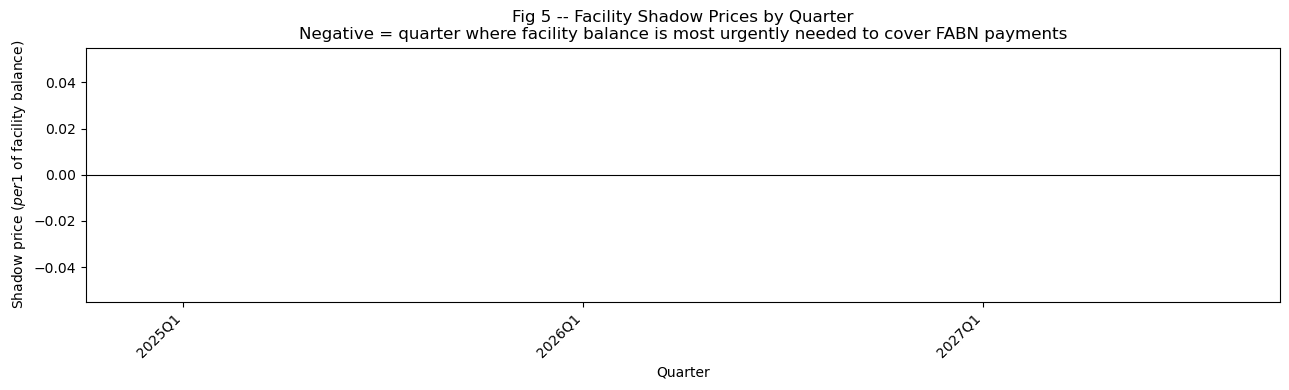

Tightest funding quarter: 2025Q1  (shadow price -0.0000)

  TABLE 2 -- NEAR-MISS BONDS
  Ranked by reduced cost: y_i - r*_hurdle (positive -> reservation price > market price).
  'Price gap': RC * MD * Price ($/100 face) -- value above market price to us.


,Rank,CUSIP,Sector,Rating,Book yield (%),Duration (yr),RBC theta_i (%),tau_i (bps),Reduced cost,Gap to entry (bps),Price gap ($/100)
0,1,AO3387922,Materials,A-,5.976,2.244,1.016,3.1,-0.00015,1.5,-0.03
1,2,880451AS8,Energy,BBB,6.089,1.907,1.523,12.2,-0.00028,2.8,-0.06
2,3,6174467Y9,Financials,A-,5.898,1.510,1.016,6.3,-0.00037,3.7,-0.05
3,4,BU3531722,Financials,A-,5.849,1.918,1.016,11.5,-0.00047,4.7,-0.09
4,5,00138EBB9,Financials,A,5.825,2.313,0.816,3.1,-0.00078,7.8,-0.18
5,6,75951BAQ9,Financials,A+,5.657,1.593,0.657,5.6,-0.00126,12.6,-0.19
6,7,40428HA44,Financials,A,5.766,1.916,0.816,2.5,-0.00131,13.1,-0.25
7,8,86563VBP3,Financials,A,5.757,1.924,0.816,3.1,-0.00134,13.4,-0.26
8,9,BR4616800,Industrials,BBB+,5.852,1.567,1.261,11.9,-0.00139,13.9,-0.21
9,10,94974BGL8,Financials,A-,5.802,2.249,1.016,6.4,-0.00157,15.7,-0.35


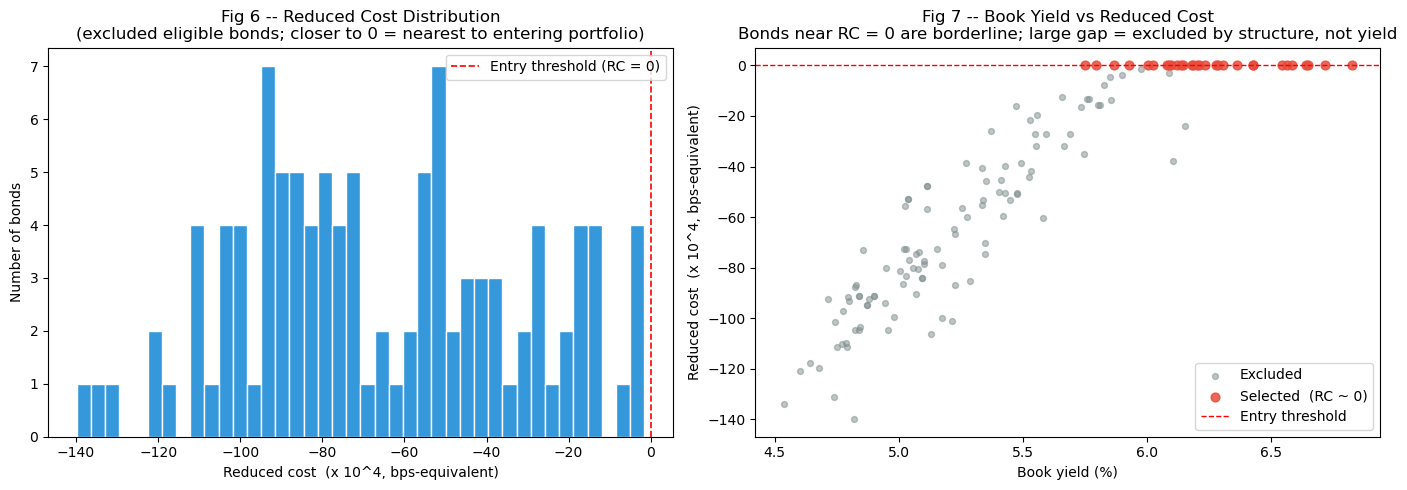

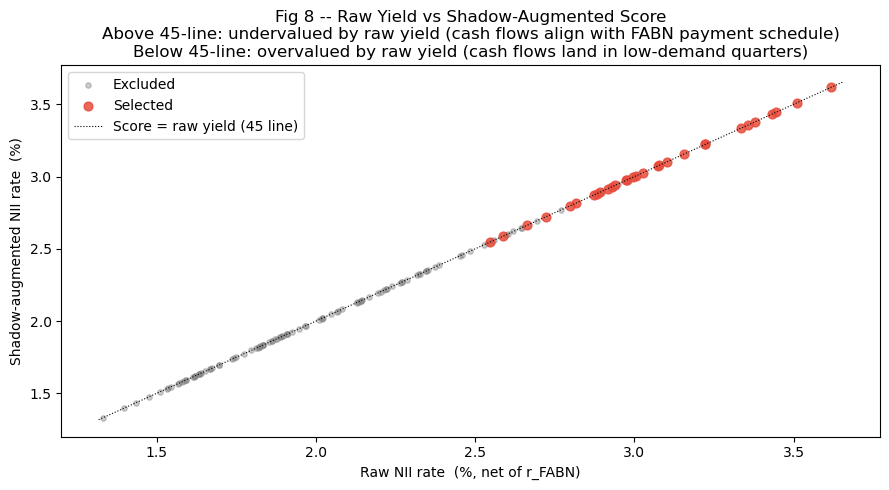


[Shadow score = book_yield_net + sum_q pi_facility[q] * CF_bond[q,i]]
Bonds above the 45-degree line contribute more than their yield implies because
their cash flows land in quarters where the lending facility needs them most.


In [37]:
# =============================================================================
# 3B. SHADOW PRICE ANALYSIS  --  always run after Section 3
# =============================================================================
if model.Status != GRB.OPTIMAL:
    print("Shadow price analysis requires an optimal solution -- skipping.")
else:
    # -- 1. Extract dual values (shadow prices) of all named constraints -------
    pi_budget    = model.getConstrByName("budget").Pi
    pi_dur_upper = model.getConstrByName("dur_upper").Pi
    pi_dur_lower = model.getConstrByName("dur_lower").Pi
    pi_facility  = np.array([model.getConstrByName(f"facility_{q}").Pi for q in range(Q)])
    pi_issuer    = {iss: model.getConstrByName(f"conc_{iss}").Pi for iss in issuer_groups}

    # -- 2. Reduced costs of bond allocation variables h[i] -------------------
    rc = np.array([h[i].RC for i in range(N)])

    # -- 2b. Marginal $ with NO issuer/diversification caps -----------------
    #        Same exercise as the Budget shadow price, but relax ONLY the
    #        issuer concentration caps (conc_*).  KEEP the CVaR limit (duration band
    #        relaxed; PV-shortfall cap removed), so the risk-relief value that makes the
    #        budget dollar worth pi_budget is preserved -- only diversification
    #        is freed.  Re-solve and read the new budget dual.  The returned
    #        principal is reinvested by the model's facility block automatically
    #        (same basis as pi_budget); a sub-funding bond is never chosen at
    #        the margin, so the "reinvestment bucket" floor is implicit.
    _m2 = model.copy()
    _m2.Params.OutputFlag = 0
    for _iss in issuer_groups:
        _m2.getConstrByName(f"conc_{_iss}").RHS = GRB.INFINITY   # drop issuer caps ONLY
    _m2.optimize()
    if _m2.Status == GRB.OPTIMAL:
        pi_unconstr  = _m2.getConstrByName("budget").Pi
        _h2          = np.array([_m2.getVarByName(f"h[{i}]").X for i in range(N)])
        best_i       = int(np.argmax(_h2 - h_opt))      # where the freed dollar flows
        _best_status = "held" if h_opt[best_i] > 1.0 else "new (was capped out)"
    else:
        pi_unconstr  = float("nan"); best_i = 0; _best_status = "re-solve failed"

    # -- 3. TABLE 1: Constraint Shadow Price Report ---------------------------
    def _yn(v): return "Yes" if abs(v) > 1e-6 else "No"
    pd.set_option("display.max_colwidth", None)   # show full Reading text (no "..." truncation)

    t1 = pd.DataFrame([
        {
            "Constraint"   : "Budget  (Sum h_i = H)",
            "Shadow price" : f"${pi_budget:+,.4f} / $1",
            "Binding?"     : "Equality",
            "Reading"      : f"$1 more capital -> ${pi_budget:,.4f} more net NII",
        },
        {
            "Constraint"   : "Marginal $  (no issuer/diversification caps)",
            "Shadow price" : f"${pi_unconstr:+,.4f} / $1",
            "Binding?"     : "n/a",
            "Reading"      : (f"vs ${pi_budget:.4f} constrained -> dropping issuer caps is worth "
                              f"${pi_unconstr - pi_budget:+,.4f}/$1; freed $ -> {CUSIPS[best_i]} [{_best_status}]"),
        },
        {
            "Constraint"   : ("Duration upper  (relaxed -- CVaR governs)" if use_cvar else f"Duration upper  (<= {eps_D} yr x H)"),
            "Shadow price" : f"${pi_dur_upper:+,.4f} / yr-$",
            "Binding?"     : _yn(pi_dur_upper),
            "Reading"      : (
                f"Binding -- widen band by 0.1 yr -> +${abs(pi_dur_upper)*0.1*H:,.0f} NII"
                if abs(pi_dur_upper) > 1e-6 else
                "Not binding -- portfolio fits naturally within upper limit"
            ),
        },
        {
            "Constraint"   : ("Duration lower  (relaxed -- CVaR governs)" if use_cvar else f"Duration lower  (<= {eps_D} yr x H)"),
            "Shadow price" : f"${pi_dur_lower:+,.4f} / yr-$",
            "Binding?"     : _yn(pi_dur_lower),
            "Reading"      : (
                f"Binding -- widen band by 0.1 yr -> +${abs(pi_dur_lower)*0.1*H:,.0f} NII"
                if abs(pi_dur_lower) > 1e-6 else
                "Not binding -- portfolio fits naturally within lower limit"
            ),
        },
    ])
    print("=" * 68)
    print("  TABLE 1 -- CONSTRAINT SHADOW PRICE REPORT")
    print("=" * 68)
    display(t1)

    # -- 4. Binding issuer concentration caps ---------------------------------
    bind_iss = sorted(
        [(iss, pi) for iss, pi in pi_issuer.items() if abs(pi) > 1e-6],
        key=lambda x: abs(x[1]), reverse=True,
    )
    print(f"\nIssuer concentration caps: {len(bind_iss)} of {len(issuer_groups)} are binding.")
    if bind_iss:
        print("Top 10 binding issuers (optimizer wants more than the 5% cap allows):")
        display(pd.DataFrame([
            {
                "Issuer (6-char CUSIP)"   : iss,
                "Shadow price"            : f"${pi:+,.4f} / $1",
                "NII gain if cap +1pp ($)": f"${abs(pi) * 0.01 * H:,.0f}",
            }
            for iss, pi in bind_iss[:10]
        ]))

    # -- 5. Chart A: Facility quarter shadow prices ----------------------------
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(
        range(Q), pi_facility,
        color=["#e74c3c" if p < 0 else "#27ae60" for p in pi_facility],
        edgecolor="white", width=0.85,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(range(0, Q, 4))
    ax.set_xticklabels([str(qtr_idx[q]) for q in range(0, Q, 4)], rotation=45, ha="right")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Shadow price ($ per $1 of facility balance)")
    ax.set_title(
        "Fig 5 -- Facility Shadow Prices by Quarter\n"
        "Negative = quarter where facility balance is most urgently needed to cover FABN payments"
    )
    plt.tight_layout(); plt.show()

    tightest_q = int(np.argmin(pi_facility))
    print(f"Tightest funding quarter: {qtr_idx[tightest_q]}  "
          f"(shadow price {pi_facility[tightest_q]:.4f})")

    # -- 6. TABLE 2: Near-miss bonds (excluded, ranked by reduced cost) --------
    # post_fabn_mask bonds are forced to zero by the maturity rule -- skip them.
    eligible = ~post_fabn_mask
    excluded = (h_opt < 1.0) & eligible
    excl_idx = np.where(excluded)[0]
    order    = np.argsort(-rc[excl_idx])   # descending: least-negative RC first

    _pf = pipeline["fixed"].set_index("CUSIP")
    t2_rows = []
    for rank, pos in enumerate(order[:20]):
        i   = excl_idx[pos]
        cid = CUSIPS[i]
        t2_rows.append({
            "Rank"              : rank + 1,
            "CUSIP"             : cid,
            "Sector"            : str(_pf.loc[cid, "sector"]),
            "Rating"            : str(_pf.loc[cid, "rating_sp"]).strip(),
            "Book yield (%)"    : f"{book_yield[i]*100:.3f}",
            "Duration (yr)"     : f"{durs[i]:.3f}",
            "RBC theta_i (%)"   : f"{theta[i]*100:.3f}",
            "tau_i (bps)"       : f"{tau[i]*1e4:.1f}",
            "Reduced cost"      : f"{rc[i]:+.5f}",
            "Gap to entry (bps)": f"{abs(rc[i])*1e4:.1f}",
            "Price gap ($/100)" : f"{durs[i] * rc[i] * price[i]:+.2f}",
        })
    print("\n" + "=" * 68)
    print("  TABLE 2 -- NEAR-MISS BONDS")
    print("  Ranked by reduced cost: y_i - r*_hurdle (positive -> reservation price > market price).")
    print("  'Price gap': RC * MD * Price ($/100 face) -- value above market price to us.")
    print("=" * 68)
    display(pd.DataFrame(t2_rows))

    # -- 7. Chart B: RC distribution + book yield vs RC scatter ---------------
    rc_excl = rc[excl_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: reduced cost distribution (all excluded eligible bonds)
    axes[0].hist(rc_excl * 1e4, bins=40, color="#3498db", edgecolor="white")
    axes[0].axvline(0, color="red", ls="--", lw=1.2, label="Entry threshold (RC = 0)")
    axes[0].set_xlabel("Reduced cost  (x 10^4, bps-equivalent)")
    axes[0].set_ylabel("Number of bonds")
    axes[0].set_title(
        "Fig 6 -- Reduced Cost Distribution\n"
        "(excluded eligible bonds; closer to 0 = nearest to entering portfolio)"
    )
    axes[0].legend()

    # Right: book yield vs reduced cost
    sel_mask = h_opt > 1.0
    axes[1].scatter(book_yield[excl_idx] * 100, rc_excl * 1e4,
                    alpha=0.5, color="#7f8c8d", s=18, label="Excluded")
    axes[1].scatter(book_yield[sel_mask] * 100, rc[sel_mask] * 1e4,
                    alpha=0.85, color="#e74c3c", s=40, label="Selected  (RC ~ 0)")
    axes[1].axhline(0, color="red", ls="--", lw=1.0, label="Entry threshold")
    axes[1].set_xlabel("Book yield (%)")
    axes[1].set_ylabel("Reduced cost  (x 10^4, bps-equivalent)")
    axes[1].set_title(
        "Fig 7 -- Book Yield vs Reduced Cost\n"
        "Bonds near RC = 0 are borderline; large gap = excluded by structure, not yield"
    )
    axes[1].legend()
    plt.tight_layout(); plt.show()

    # -- 8. Shadow-augmented facility fit score --------------------------------
    # For each bond compute the bonus value from its cash-flow timing:
    #   bonus_i = sum_q  pi_facility[q] * CF_bond[q, i]   (per $1 of h_i)
    # A positive bonus means the bond's payments fall in quarters where the FABN
    # needs liquidity most -- it is worth more than its raw yield implies.
    fac_bonus  = np.array([
        sum(float(pi_facility[q]) * float(qtr_bond_cf[q, i]) for q in range(Q))
        for i in range(N)
    ])
    shadow_nii = nii_rate + fac_bonus    # shadow-augmented NII rate

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(
        nii_rate[~sel_mask & eligible] * 100,
        shadow_nii[~sel_mask & eligible] * 100,
        alpha=0.4, color="grey", s=15, label="Excluded",
    )
    ax.scatter(
        nii_rate[sel_mask] * 100,
        shadow_nii[sel_mask] * 100,
        alpha=0.85, color="#e74c3c", s=40, label="Selected",
    )
    _lo = min(nii_rate[eligible].min(), shadow_nii[eligible].min()) * 100 * 0.99
    _hi = max(nii_rate[eligible].max(), shadow_nii[eligible].max()) * 100 * 1.01
    ax.plot([_lo, _hi], [_lo, _hi], "k:", lw=0.8, label="Score = raw yield (45 line)")
    ax.set_xlabel("Raw NII rate  (%, net of r_FABN)")
    ax.set_ylabel("Shadow-augmented NII rate  (%)")
    ax.set_title(
        "Fig 8 -- Raw Yield vs Shadow-Augmented Score\n"
        "Above 45-line: undervalued by raw yield (cash flows align with FABN payment schedule)\n"
        "Below 45-line: overvalued by raw yield (cash flows land in low-demand quarters)"
    )
    ax.legend()
    plt.tight_layout(); plt.show()

    print("\n[Shadow score = book_yield_net + sum_q pi_facility[q] * CF_bond[q,i]]")
    print("Bonds above the 45-degree line contribute more than their yield implies because")
    print("their cash flows land in quarters where the lending facility needs them most.")

In [38]:
# ---- Quick bond lookup: paste a CUSIP, get maturity / duration / price / yield ----
cusip = "456837AH6"     # <-- put your CUSIP here

_fx = pipeline["fixed"].set_index("CUSIP")
if cusip not in CUSIPS:
    print(f"{cusip} not in the optimizer universe (N={len(CUSIPS)} bonds).")
else:
    i   = CUSIPS.index(cusip)
    mat = pd.to_datetime(_fx.loc[cusip, "maturity"]).date()
    print(f"CUSIP        : {cusip}")
    print(f"Maturity     : {mat}")
    print(f"Duration     : {durs[i]:.3f} yrs (modified)")
    print(f"Price        : {price[i]:.3f}  (per 100 face)")
    print(f"Book yield   : {book_yield[i]*100:.3f}%")
    print(f"Net of r_FABN: {(book_yield[i]-r_FABN)*100:+.3f}%   (yield - {r_FABN*100:.3f}%)")
    # allocation context, if Section 3 has run:
    try:
        print(f"Held (h_opt) : ${h_opt[i]:,.0f}   ({h_opt[i]/H*100:.2f}% of budget)")
    except NameError:
        pass

CUSIP        : 456837AH6
Maturity     : 2027-03-29
Duration     : 2.006 yrs (modified)
Price        : 98.208  (per 100 face)
Book yield   : 5.476%
Net of r_FABN: +2.271%   (yield - 3.205%)
Held (h_opt) : $0   (0.00% of budget)


---
## Section 3B-ii — Per-Bond Reservation Price (Shadow Price)

The LP implicitly computes a **hurdle yield** $r^*_i$ for every bond — the minimum yield the bond
must offer (given its duration, credit, and cash-flow timing) for the optimizer to want it.

$$r^*_i = y_i - RC_i$$

where $y_i$ is the bond's book yield and $RC_i$ is its reduced cost from the LP.

The **reservation price** (shadow price) is the PV of the bond's cash flows discounted at $r^*_i$:

$$P^*_i = \sum_t CF_{t,i}\,(1 + r^*_i)^{-t} \times 100$$

| Interpretation | Condition |
|---|---|
| Bond is **underpriced** for us (optimizer wants it) | $P^*_i > P^{mkt}_i$ (gap > 0) |
| Bond is **overpriced** for us (optimizer rejects it) | $P^*_i < P^{mkt}_i$ (gap < 0) |
| Bond is **at the margin** (just entering/leaving) | $P^*_i \approx P^{mkt}_i$ (gap ≈ 0) |

  TABLE 3 — PER-BOND RESERVATION PRICE (SHADOW PRICE)
  P*_i = PV(bond CFs at hurdle yield r*_i).  Gap = P* − Market Price.
  Gap > 0 → bond is cheap for us.  Gap < 0 → bond is expensive for us.
  Bonds with P* > P (underpriced for portfolio) : 0
  Bonds with P* ≈ P (at the margin)            : 0
  Bonds with P* < P (overpriced for portfolio)  : 119

  TOP 20 — highest shadow-price premium (bonds the optimizer values most):


,CUSIP,Sector,Rating,Mkt Price ($/100),Shadow Price P*,Gap (P*−P),Gap (%),Book Yield (%),Hurdle r* (%),Duration (yr),Selected
0,ZI8616628,Utilities,AA-,100.636,100.223,-0.413,-0.41,6.145,6.145,1.529,YES
1,ZI8715974,Financials,AA+,101.428,100.990,-0.438,-0.43,5.751,5.751,1.526,YES
2,75951BAQ9,Financials,A+,93.940,93.490,-0.450,-0.48,5.657,5.783,1.593,
3,BR4616800,Industrials,BBB+,95.407,94.850,-0.557,-0.58,5.852,5.991,1.567,
4,880451AS8,Energy,BBB,104.363,103.757,-0.606,-0.58,6.089,6.117,1.907,
5,AM6439740,Financials,BBB+,98.300,97.682,-0.618,-0.63,6.135,6.135,1.937,YES
6,61238QAA6,Materials,BBB,105.485,104.866,-0.619,-0.59,6.823,6.823,1.880,YES
7,6174467Y9,Financials,A-,99.270,98.620,-0.650,-0.65,5.898,5.935,1.510,
8,66815M2R7,Financials,AA+,100.908,100.253,-0.655,-0.65,5.470,5.629,1.973,
9,AO8886308,Financials,BBB,95.765,95.015,-0.750,-0.78,6.360,6.360,2.347,YES



  BOTTOM 20 — largest shadow-price discount (bonds furthest from entering):


,CUSIP,Sector,Rating,Mkt Price ($/100),Shadow Price P*,Gap (P*−P),Gap (%),Book Yield (%),Hurdle r* (%),Duration (yr),Selected
99,22535WAB3,Financials,A-,98.360,95.404,-2.956,-3.01,5.093,5.935,1.835,
100,AN2054384,Financials,A,97.741,94.769,-2.972,-3.04,5.028,5.861,2.078,
101,46115HBB2,Financials,BBB+,96.799,93.737,-3.062,-3.16,5.346,6.091,2.277,
102,59217HDB0,Financials,AA-,94.744,91.614,-3.130,-3.30,4.742,5.758,1.872,
103,44891CCT8,Consumer Discretionary,A-,100.562,97.393,-3.169,-3.15,5.069,5.973,1.814,
104,86562MCM0,Financials,A,95.099,91.920,-3.179,-3.34,4.840,5.885,1.873,
105,89114TZN5,Financials,A,94.733,91.541,-3.192,-3.37,4.822,5.868,1.872,
106,191216CE8,Consumer Staples,A+,96.689,93.478,-3.211,-3.32,4.641,5.820,2.187,
107,53944YAD5,Financials,A-,97.859,94.642,-3.217,-3.29,4.979,5.973,1.843,
108,58769JAQ0,Consumer Discretionary,A,100.084,96.756,-3.328,-3.33,4.844,5.878,1.832,


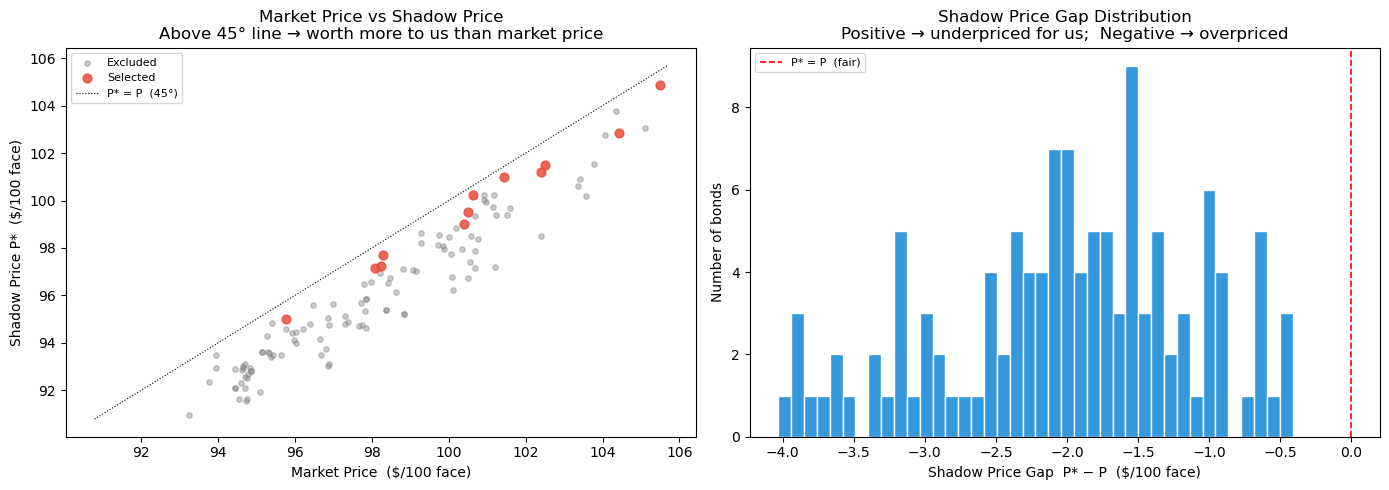


Shadow price gap stats (eligible bonds, $/100 face):
  Mean gap   : -1.987
  Median gap : -1.914
  Max (most underpriced) : -0.413  (bond ZI8616628)
  Min (most overpriced)  : -4.031  (bond 502431AP4)


In [39]:
# =============================================================================
# 3B-ii. PER-BOND RESERVATION PRICE (SHADOW PRICE)  --  always run after 3B
# =============================================================================
if model.Status == GRB.OPTIMAL:
    # -- 1. Hurdle yield and reservation price for every eligible bond ---------
    r_star = book_yield - rc                           # r*_i = y_i - RC_i
    P_star = np.full(N, np.nan)
    t_q_arr = np.array(t_quarters)
    for i in range(N):
        cfs = qtr_bond_cf[:, i]                        # per $1 face
        if cfs.sum() < 1e-12 or r_star[i] <= -1:
            continue
        P_star[i] = float((cfs * (1.0 + r_star[i]) ** (-t_q_arr)).sum()) * 100.0

    gap = P_star - price                               # $/100 face

    # -- 2. TABLE 3: full bond list sorted by gap ----------------------------
    _pf = pipeline["fixed"].set_index("CUSIP")
    t3_rows = []
    for i in range(N):
        if post_fabn_mask[i] or np.isnan(P_star[i]):
            continue
        cid = CUSIPS[i]
        t3_rows.append({
            "CUSIP"               : cid,
            "Sector"              : str(_pf.loc[cid, "sector"]),
            "Rating"              : str(_pf.loc[cid, "rating_sp"]).strip(),
            "Mkt Price ($/100)"   : round(price[i], 3),
            "Shadow Price P*"     : round(P_star[i], 3),
            "Gap (P*−P)"          : round(gap[i], 3),
            "Gap (%)"             : round(gap[i] / price[i] * 100, 2),
            "Book Yield (%)"      : round(book_yield[i] * 100, 3),
            "Hurdle r* (%)"       : round(r_star[i] * 100, 3),
            "Duration (yr)"       : round(durs[i], 3),
            "Selected"            : "YES" if h_opt[i] > 1.0 else "",
        })
    t3_df = pd.DataFrame(t3_rows).sort_values("Gap (P*−P)", ascending=False).reset_index(drop=True)

    n_pos = int((t3_df["Gap (P*−P)"] > 0.001).sum())
    n_neg = int((t3_df["Gap (P*−P)"] < -0.001).sum())
    n_par = len(t3_df) - n_pos - n_neg

    print("=" * 72)
    print("  TABLE 3 — PER-BOND RESERVATION PRICE (SHADOW PRICE)")
    print("  P*_i = PV(bond CFs at hurdle yield r*_i).  Gap = P* − Market Price.")
    print("  Gap > 0 → bond is cheap for us.  Gap < 0 → bond is expensive for us.")
    print("=" * 72)
    print(f"  Bonds with P* > P (underpriced for portfolio) : {n_pos}")
    print(f"  Bonds with P* ≈ P (at the margin)            : {n_par}")
    print(f"  Bonds with P* < P (overpriced for portfolio)  : {n_neg}")
    print(f"\n  TOP 20 — highest shadow-price premium (bonds the optimizer values most):")
    display(t3_df.head(20))
    print(f"\n  BOTTOM 20 — largest shadow-price discount (bonds furthest from entering):")
    display(t3_df.tail(20))

    # -- 3. Charts: Market Price vs Shadow Price + Gap distribution -----------
    elig_fin = ~post_fabn_mask & np.isfinite(P_star)
    P_e   = price[elig_fin]
    PS_e  = P_star[elig_fin]
    sel_e = h_opt[elig_fin] > 1.0
    gap_e = gap[elig_fin]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(P_e[~sel_e], PS_e[~sel_e], alpha=0.4, color="grey", s=15, label="Excluded")
    axes[0].scatter(P_e[sel_e],  PS_e[sel_e],  alpha=0.85, color="#e74c3c", s=40, label="Selected")
    _lo = min(P_e.min(), PS_e.min()) * 0.998
    _hi = max(P_e.max(), PS_e.max()) * 1.002
    axes[0].plot([_lo, _hi], [_lo, _hi], "k:", lw=0.8, label="P* = P  (45°)")
    axes[0].set_xlabel("Market Price  ($/100 face)")
    axes[0].set_ylabel("Shadow Price P*  ($/100 face)")
    axes[0].set_title("Market Price vs Shadow Price\nAbove 45° line → worth more to us than market price")
    axes[0].legend(fontsize=8)

    axes[1].hist(gap_e, bins=40, color="#3498db", edgecolor="white")
    axes[1].axvline(0, color="red", ls="--", lw=1.2, label="P* = P  (fair)")
    axes[1].set_xlabel("Shadow Price Gap  P* − P  ($/100 face)")
    axes[1].set_ylabel("Number of bonds")
    axes[1].set_title("Shadow Price Gap Distribution\nPositive → underpriced for us;  Negative → overpriced")
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    # -- 4. Summary stats -----------------------------------------------------
    print(f"\nShadow price gap stats (eligible bonds, $/100 face):")
    print(f"  Mean gap   : {gap_e.mean():+.3f}")
    print(f"  Median gap : {np.median(gap_e):+.3f}")
    print(f"  Max (most underpriced) : {gap_e.max():+.3f}  (bond {CUSIPS[np.where(elig_fin)[0][np.argmax(gap_e)]]})")
    print(f"  Min (most overpriced)  : {gap_e.min():+.3f}  (bond {CUSIPS[np.where(elig_fin)[0][np.argmin(gap_e)]]})")
else:
    print("Reservation price analysis requires an optimal solution -- skipping.")

---
## Section 3B-iii — Marginal Dollar of Capital: Range, Breakdown & Diversification Gap

Three diagnostics on the budget shadow price:

1. **Range of H.** Over what interval of the budget does the shadow price stay
   valid, and how does the marginal value of capital evolve as the budget grows?
   *(Gurobi RHS-ranging `SARHSLow/SARHSUp` + a robust parametric re-solve sweep.)*
2. **Breakdown by term.** What is $\pi_{budget}$ made of — NII, facility savings,
   capital cost, …? *(Perturb the budget right-hand side, re-solve, attribute the
   change in each objective term: $d\,\text{SAP}^*/dH = \pi_{budget}$.)*
3. **Diversification gap.** The same two analyses for the *no-issuer-caps* marginal
   dollar $\pi_{unconstr}$ and the **gap** $\pi_{unconstr}-\pi_{budget}$ — the value
   the issuer/diversification caps hold back per marginal dollar, and how it scales.

**Convention.** This is pure **budget RHS-ranging**: only the budget constraint's
right-hand side moves; the duration target, issuer caps and swap cap stay at their
base-case ($H$) levels — the same ceteris-paribus basis under which $\pi_{budget}$
is defined. The *unconstrained* variant additionally drops the issuer caps (only),
keeping the duration band, exactly as in Section 3B.


Sweeping budget H over 59 points x2 (constrained + no-caps) ...
Done.
  TABLE 4 -- MARGINAL DOLLAR: SHADOW PRICE & VALID RANGE OF H


,Marginal dollar,Shadow price ($/$1),Valid H range (sweep),Valid H range (Gurobi SARHS)
0,Under all constraints,$0.0229,$470M - $512M,$493M - $513M
1,No issuer/diversification caps,$0.0295,$250M - $700M,-


  Diversification-cap gap (pi_unconstr - pi_budget): $+0.0066 / $1
  -> at H=$500M the issuer caps hold back $0.0066 of value per marginal dollar.

  TABLE 5 -- SHADOW PRICE BREAKDOWN BY OBJECTIVE TERM ($ per $1)
  (finite-difference dH: constrained $1,000,000, no-caps $1,000,000;
   TOTAL should match pi_budget +0.0229 / pi_unconstr +0.0295)


,Term,pi_budget ($/$1),pi_unconstr ($/$1),Gap contribution
0,NII (spread over funding),+0.0298,+0.0336,+0.0038
1,Savings (principal reinvest),+0.0000,+0.0000,+0.0000
2,Capital cost (lambda*theta),-0.0057,-0.0037,+0.0020
3,Turnover,-0.0004,-0.0004,-0.0000
4,Swap NII,+0.0000,+0.0000,+0.0000
5,Swap capital,-0.0008,+0.0000,+0.0008
6,TOTAL (= shadow price),+0.0229,+0.0295,+0.0066


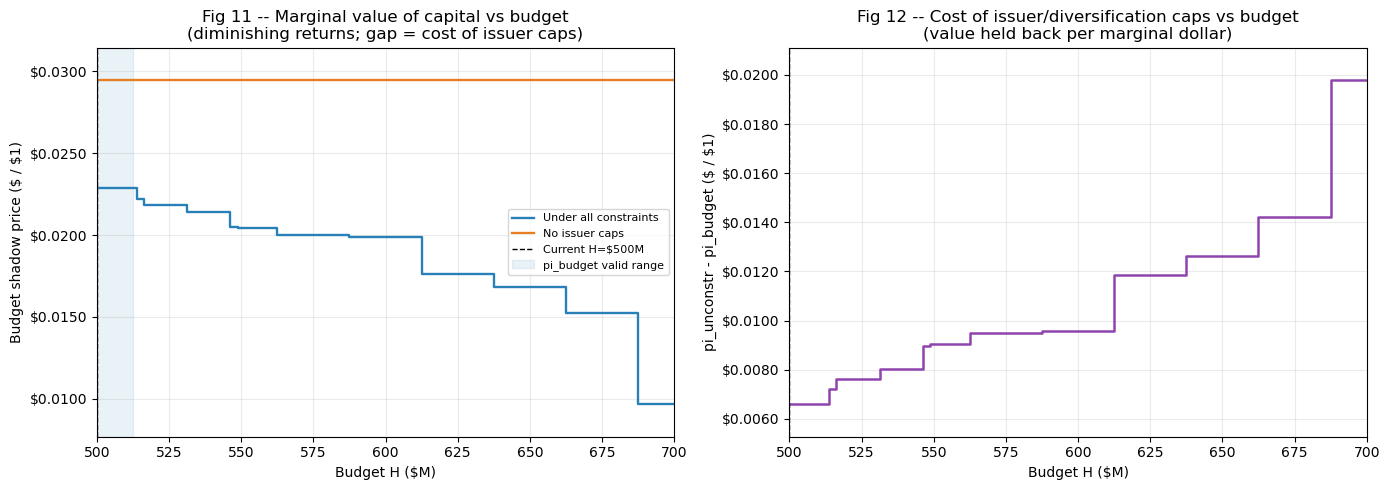

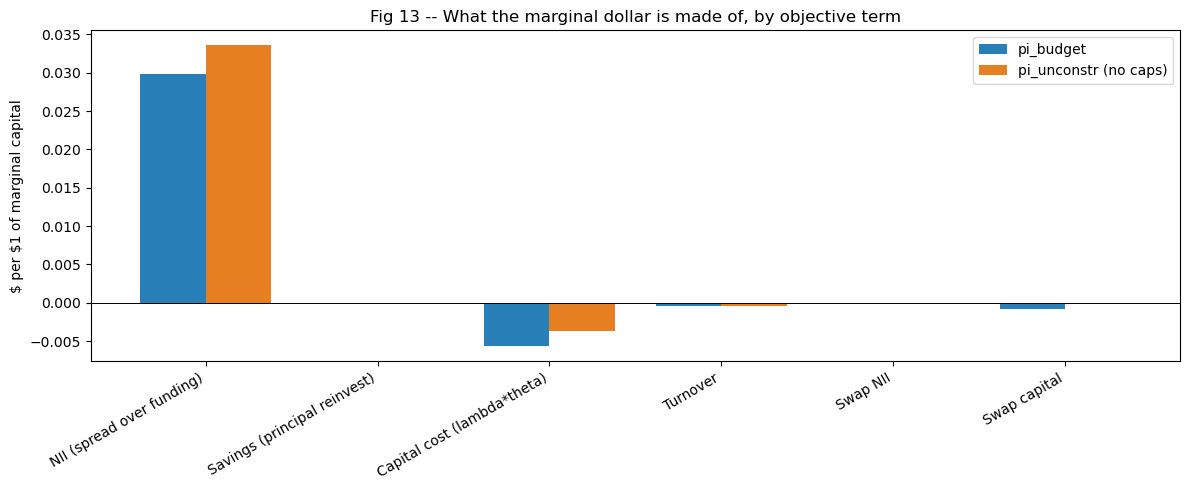


Reading:
  - pi_budget = $+0.0229/$1, valid while H in [$470M, $512M].
  - Dropping issuer caps lifts it to $+0.0295/$1 (gap $+0.0066).
  - Composition: NII +0.0298 + Savings +0.0000 + Capital -0.0057 (+ small terms) per $1.


In [40]:
# =============================================================================
# 3B-iii. MARGINAL DOLLAR — RANGE, BREAKDOWN & DIVERSIFICATION GAP
# =============================================================================
# Pure budget RHS-ranging: only the "budget" RHS moves; duration target, issuer
# caps and swap cap stay at their base-case (H) levels -- the ceteris-paribus
# basis under which pi_budget is defined.  "unconstr" additionally drops the
# issuer caps only (keeps the duration band), exactly as Section 3B does.
if model.Status != GRB.OPTIMAL:
    print("3B-iii requires an optimal base solution -- skipping.")
else:
    _terms = ["NII", "Savings", "Capital", "Turnover", "SwapNII", "SwapCap"]

    def _resolve_budget(H_new, drop_caps=False):
        m = model.copy(); m.Params.OutputFlag = 0
        m.getConstrByName("budget").RHS = float(H_new)
        if drop_caps:
            for _iss in issuer_groups:
                m.getConstrByName(f"conc_{_iss}").RHS = GRB.INFINITY
        m.optimize()
        return m

    def _pi_of(m):
        return m.getConstrByName("budget").Pi if m.Status == GRB.OPTIMAL else float("nan")

    def _components(m):
        """Objective decomposition of a solved (copied) model, signed as in SAP."""
        if m.Status != GRB.OPTIMAL:
            return {k: float("nan") for k in _terms + ["SAP"]}
        hv  = np.array([m.getVarByName(f"h[{i}]").X       for i in range(N)])
        Bv  = np.array([m.getVarByName(f"B[{q}]").X       for q in range(Q)])
        snv = np.array([m.getVarByName(f"s_net[{q}]").X   for q in range(Q)])
        tpv = np.array([m.getVarByName(f"tc_plus[{i}]").X for i in range(N)])
        tmv = np.array([m.getVarByName(f"tc_minus[{i}]").X for i in range(N)])
        nii = float((nii_rate * hv).sum())
        cap = lambda_cap * float((theta * hv).sum())
        txn = float((tau * (tpv + tmv)).sum())
        liq = eta * float((np.array(df_q) * snv).sum())
        sav = r_save * dt_q * float(Bv[:Q - 1].sum())
        if use_swaps and K > 0:
            vv  = np.array([m.getVarByName(f"v[{k}]").X for k in range(K)])
            sni = float(sum((swap_rates_k[k] - r_float) * vv[k] for k in range(K)))
            sca = lambda_cap * mu_swap * float(vv.sum())
        else:
            sni = 0.0; sca = 0.0
        return {"NII": nii, "Savings": sav, "Capital": -cap, "Turnover": -txn,
                "Liquidity": -liq, "SwapNII": sni, "SwapCap": -sca, "SAP": m.ObjVal}

    # ---- (1) Parametric budget sweep -----------------------------------------
    # Dense grid near H (to resolve a narrow validity band) + broad context.
    H_grid = np.unique(np.concatenate([
        H * np.linspace(0.5, 1.6, 23),        # broad context for the curve
        np.linspace(H * 0.90, H * 1.10, 41),  # fine ~$2.5M steps around H
        [float(H)],                           # exact anchor at the current budget
    ]))
    print(f"Sweeping budget H over {len(H_grid)} points x2 (constrained + no-caps) ...")
    pi_con = np.array([_pi_of(_resolve_budget(Hn, drop_caps=False)) for Hn in H_grid])
    pi_unc = np.array([_pi_of(_resolve_budget(Hn, drop_caps=True))  for Hn in H_grid])
    print("Done.")

    def _valid_range(grid, pis, pi_here):
        """Contiguous H-interval around current H where the dual == pi_here."""
        j = int(np.argmin(np.abs(grid - H))); lo = hi = grid[j]; k = j
        while k - 1 >= 0 and np.isfinite(pis[k-1]) and abs(pis[k-1] - pi_here) <= 1e-4:
            k -= 1; lo = grid[k]
        k = j
        while k + 1 < len(grid) and np.isfinite(pis[k+1]) and abs(pis[k+1] - pi_here) <= 1e-4:
            k += 1; hi = grid[k]
        return lo, hi

    seg_lo,  seg_hi  = _valid_range(H_grid, pi_con, pi_budget)
    segu_lo, segu_hi = _valid_range(H_grid, pi_unc, pi_unconstr)

    try:                                   # Gurobi's own RHS-ranging (needs a basis)
        sarhs_lo = model.getConstrByName("budget").SARHSLow
        sarhs_hi = model.getConstrByName("budget").SARHSUp
    except Exception:
        sarhs_lo = sarhs_hi = float("nan")

    # ---- (2) Term-by-term breakdown ------------------------------------------
    def _breakdown(drop_caps):
        base = _resolve_budget(H, drop_caps=drop_caps)
        lo, hi = _valid_range(H_grid, pi_unc if drop_caps else pi_con, _pi_of(base))
        dH = min(1.0e6, 0.4 * (hi - H)) if hi > H + 1.0 else 1.0e5
        up = _resolve_budget(H + dH, drop_caps=drop_caps)
        c0, c1 = _components(base), _components(up)
        return {k: (c1[k] - c0[k]) / dH for k in _terms}, _pi_of(base), dH

    bd_con, _pc, dH_con = _breakdown(False)
    bd_unc, _pu, dH_unc = _breakdown(True)
    bd_gap = {k: bd_unc[k] - bd_con[k] for k in _terms}

    # ---- TABLE 4: shadow price & valid range ---------------------------------
    pd.set_option("display.max_colwidth", None)
    rng = pd.DataFrame([
        {"Marginal dollar": "Under all constraints",
         "Shadow price ($/$1)": f"${pi_budget:,.4f}",
         "Valid H range (sweep)": f"${seg_lo/1e6:,.0f}M - ${seg_hi/1e6:,.0f}M",
         "Valid H range (Gurobi SARHS)":
            (f"${sarhs_lo/1e6:,.0f}M - ${sarhs_hi/1e6:,.0f}M" if np.isfinite(sarhs_lo) else "n/a (no basis)")},
        {"Marginal dollar": "No issuer/diversification caps",
         "Shadow price ($/$1)": f"${pi_unconstr:,.4f}",
         "Valid H range (sweep)": f"${segu_lo/1e6:,.0f}M - ${segu_hi/1e6:,.0f}M",
         "Valid H range (Gurobi SARHS)": "-"},
    ])
    print("=" * 72)
    print("  TABLE 4 -- MARGINAL DOLLAR: SHADOW PRICE & VALID RANGE OF H")
    print("=" * 72)
    display(rng)
    print(f"  Diversification-cap gap (pi_unconstr - pi_budget): "
          f"${pi_unconstr - pi_budget:+,.4f} / $1")
    print(f"  -> at H=${H/1e6:,.0f}M the issuer caps hold back "
          f"${pi_unconstr - pi_budget:.4f} of value per marginal dollar.")

    # ---- TABLE 5: breakdown by objective term --------------------------------
    _lbl = {"NII": "NII (spread over funding)", "Savings": "Savings (principal reinvest)",
            "Capital": "Capital cost (lambda*theta)", "Turnover": "Turnover",
            "Liquidity": "Liquidity", "SwapNII": "Swap NII", "SwapCap": "Swap capital"}
    bd = pd.DataFrame([
        {"Term": _lbl[k], "pi_budget ($/$1)": f"{bd_con[k]:+.4f}",
         "pi_unconstr ($/$1)": f"{bd_unc[k]:+.4f}", "Gap contribution": f"{bd_gap[k]:+.4f}"}
        for k in _terms
    ])
    bd.loc[len(bd)] = ["TOTAL (= shadow price)",
                       f"{sum(bd_con[k] for k in _terms):+.4f}",
                       f"{sum(bd_unc[k] for k in _terms):+.4f}",
                       f"{sum(bd_gap[k] for k in _terms):+.4f}"]
    print("\n" + "=" * 72)
    print("  TABLE 5 -- SHADOW PRICE BREAKDOWN BY OBJECTIVE TERM ($ per $1)")
    print(f"  (finite-difference dH: constrained ${dH_con:,.0f}, no-caps ${dH_unc:,.0f};")
    print(f"   TOTAL should match pi_budget {pi_budget:+.4f} / pi_unconstr {pi_unconstr:+.4f})")
    print("=" * 72)
    display(bd)

    # ---- Charts --------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].step(H_grid / 1e6, pi_con, where="mid", color="#2980b9", lw=1.7,
                 label="Under all constraints")
    axes[0].step(H_grid / 1e6, pi_unc, where="mid", color="#e67e22", lw=1.7,
                 label="No issuer caps")
    axes[0].axvline(H / 1e6, color="k", ls="--", lw=1.0, label=f"Current H=${H/1e6:.0f}M")
    axes[0].axvspan(seg_lo / 1e6, seg_hi / 1e6, color="#2980b9", alpha=0.10,
                    label="pi_budget valid range")
    axes[0].set_xlabel("Budget H ($M)"); axes[0].set_ylabel(r"Budget shadow price (\$ / \$1)")
    axes[0].set_title("Fig 11 -- Marginal value of capital vs budget\n"
                      "(diminishing returns; gap = cost of issuer caps)")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

    gap_curve = pi_unc - pi_con
    axes[1].step(H_grid / 1e6, gap_curve, where="mid", color="#8e44ad", lw=1.8)
    axes[1].axvline(H / 1e6, color="k", ls="--", lw=1.0)
    axes[1].axhline(0, color="k", lw=0.6)
    axes[1].set_xlabel("Budget H ($M)")
    axes[1].set_ylabel(r"pi_unconstr - pi_budget (\$ / \$1)")
    axes[1].set_title("Fig 12 -- Cost of issuer/diversification caps vs budget\n"
                      "(value held back per marginal dollar)")
    axes[1].grid(alpha=0.25)
    # Option A: zoom both H-curves to a realistic +/-15% neighbourhood of the
    # current budget.  Far from H the ceteris-paribus convention (fixed duration
    # target & caps) distorts the curve, so only the neighbourhood is shown.
    from matplotlib.ticker import FuncFormatter
    _xlo, _xhi = 500.0, 700.0   # zoom window ($M), tight & symmetric around H=$500M
    _win = (H_grid / 1e6 >= _xlo) & (H_grid / 1e6 <= _xhi)
    _fmt = FuncFormatter(lambda v, _: f"${v:.4f}")
    for _ax, _yd in ((axes[0], np.concatenate([pi_con[_win], pi_unc[_win]])),
                     (axes[1], gap_curve[_win])):
        _ax.set_xlim(_xlo, _xhi)
        _yv = _yd[np.isfinite(_yd)]
        if _yv.size:
            _pad = max((_yv.max() - _yv.min()) * 0.10, 5e-4)
            _ax.set_ylim(_yv.min() - _pad, _yv.max() + _pad)
        _ax.yaxis.set_major_formatter(_fmt)
    plt.tight_layout(); plt.show()

    x = np.arange(len(_terms)); wb = 0.38
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - wb/2, [bd_con[k] for k in _terms], wb, label="pi_budget", color="#2980b9")
    ax.bar(x + wb/2, [bd_unc[k] for k in _terms], wb, label="pi_unconstr (no caps)", color="#e67e22")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xticks(x); ax.set_xticklabels([_lbl[k] for k in _terms], rotation=30, ha="right")
    ax.set_ylabel(r"\$ per \$1 of marginal capital")
    ax.set_title("Fig 13 -- What the marginal dollar is made of, by objective term")
    ax.legend(); plt.tight_layout(); plt.show()

    print("\nReading:")
    print(f"  - pi_budget = ${pi_budget:+.4f}/$1, valid while H in "
          f"[${seg_lo/1e6:.0f}M, ${seg_hi/1e6:.0f}M].")
    print(f"  - Dropping issuer caps lifts it to ${pi_unconstr:+.4f}/$1 "
          f"(gap ${pi_unconstr - pi_budget:+.4f}).")
    print(f"  - Composition: NII {bd_con['NII']:+.4f} + Savings {bd_con['Savings']:+.4f} "
          f"+ Capital {bd_con['Capital']:+.4f} (+ small terms) per $1.")


---
## Section 3C — Swap Overlay Analytics

Duration attribution and quarterly cash-flow contribution from the swap overlay.


C:\Users\lalot\AppData\Local\Temp\ipykernel_36900\4237398316.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


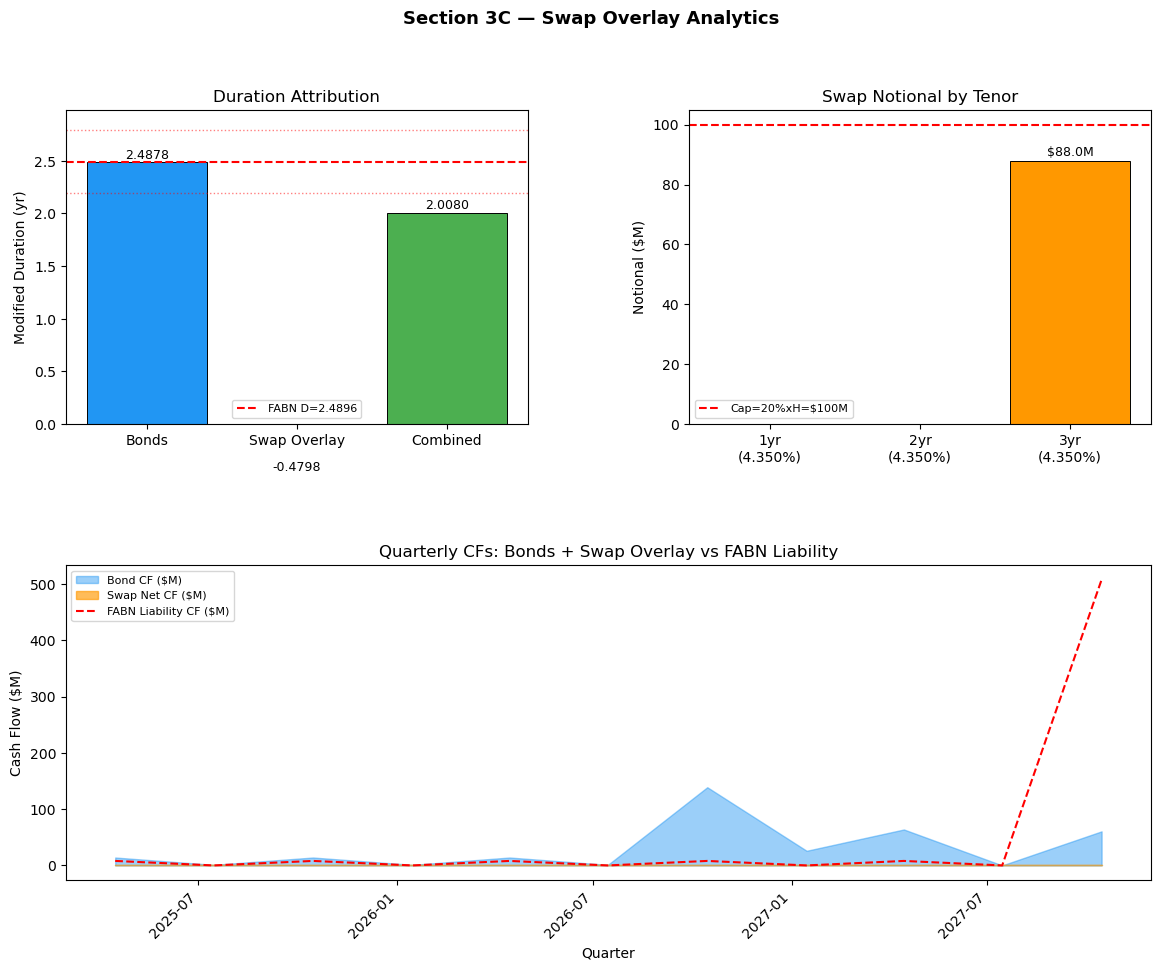

Saved: fig_swap_overlay.png


In [41]:
# =============================================================================
# 3C. SWAP OVERLAY ANALYTICS  --  Duration attribution & CF contribution
# =============================================================================
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

if use_swaps and K > 0 and v_opt.sum() > 1.0:
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

    # 3C-1: Duration attribution (stacked bar)
    ax1 = fig.add_subplot(gs[0, 0])
    dur_bond_contrib = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    dur_swap_contrib = float(sum(D_swap[k] * v_opt[k] for k in range(K))) / H
    vals   = [dur_bond_contrib, dur_swap_contrib, D_eff]
    colors = ["#2196F3", "#FF9800", "#4CAF50"]
    labels = ["Bonds", "Swap Overlay", "Combined"]
    bars = ax1.bar(labels, vals, color=colors, edgecolor="k", linewidth=0.7)
    ax1.axhline(D_FABN, color="red", linestyle="--", linewidth=1.5, label=f"FABN D={D_FABN:.4f}")
    ax1.axhline(D_FABN + eps_D, color="red", linestyle=":", linewidth=1, alpha=0.5)
    ax1.axhline(D_FABN - eps_D, color="red", linestyle=":", linewidth=1, alpha=0.5)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    ax1.set_ylabel("Modified Duration (yr)")
    ax1.set_title("Duration Attribution")
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, max(vals) * 1.20)

    # 3C-2: Swap notional by tenor
    ax2 = fig.add_subplot(gs[0, 1])
    tenors_str = [f"{swap_maturities[k]:.0f}yr\n({swap_rates_k[k]:.3%})" for k in range(K)]
    bars2 = ax2.bar(tenors_str, v_opt / 1e6, color="#FF9800", edgecolor="k", linewidth=0.7)
    cap_line = swap_cap_pct * H / 1e6
    ax2.axhline(cap_line, color="red", linestyle="--", linewidth=1.5,
                label=f"Cap={swap_cap_pct:.0%}xH=${cap_line:.0f}M")
    for bar, val in zip(bars2, v_opt / 1e6):
        if val > 0.5:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"${val:.1f}M", ha="center", va="bottom", fontsize=9)
    ax2.set_ylabel("Notional ($M)")
    ax2.set_title("Swap Notional by Tenor")
    ax2.legend(fontsize=8)

    # 3C-3: Quarterly cash flows (bonds + swap vs liability) across all quarters
    ax3 = fig.add_subplot(gs[1, :])
    q_dates = [optimization_date + pd.DateOffset(months=3*(q+1)) for q in range(Q)]
    cf_bonds_q = np.array([float(sum(qtr_bond_cf[q, i] * h_opt[i] for i in range(N)))
                            for q in range(Q)])
    cf_swap_q  = np.array([float(sum(cf_swap[k, q] * v_opt[k] for k in range(K)))
                            for q in range(Q)])
    cf_liab_q  = np.array([float(qtr_fabn_cf[q]) for q in range(Q)])
    ax3.fill_between(q_dates, cf_bonds_q / 1e6, alpha=0.45, color="#2196F3",
                     label="Bond CF ($M)")
    ax3.fill_between(q_dates, cf_swap_q / 1e6,  alpha=0.65, color="#FF9800",
                     label="Swap Net CF ($M)")
    ax3.plot(q_dates, cf_liab_q / 1e6, color="red", linewidth=1.5, linestyle="--",
             label="FABN Liability CF ($M)")
    ax3.set_xlabel("Quarter")
    ax3.set_ylabel("Cash Flow ($M)")
    ax3.set_title("Quarterly CFs: Bonds + Swap Overlay vs FABN Liability")
    ax3.legend(fontsize=8)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.suptitle("Section 3C — Swap Overlay Analytics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("Saved: fig_swap_overlay.png")
else:
    print("Swap overlay not active (use_swaps=False or optimizer allocated zero notional).")


---
## Section 4 — Analytics

In [42]:
# =============================================================================
# 4. ANALYTICS  --  always run
# =============================================================================
fixed_df = pipeline["fixed"].set_index("CUSIP")
selected = h_opt > 1.0
w        = h_opt[selected] / h_opt[selected].sum()

# -- 4A. Objective decomposition table ----------------------------------------
sap_summary = pd.DataFrame({
    "Component": ["Statutory NII", "  - coupon income", "  - amortization",
                  "Savings income", "Capital cost (lambda*RBC)",
                  "Turnover cost", "SAP OBJECTIVE"],
    "Value ($)": [nii_val, coupon_val, amort_val, savings_val,
                  -capital_cost_val, -turnover_val, sap_val],
})
display(sap_summary)

# -- 4B. Portfolio analytics --------------------------------------------------
analytics = pd.DataFrame({
    "Metric": ["Bonds selected (h>$1)", "Wtd avg book yield (%)",
               "Wtd avg coupon yield (%)", "Wtd avg amortization (bps)",
               "Wtd avg OAS spread (bps)", "Wtd avg duration (yrs)",
               "Wtd avg RBC factor (%)", "Statutory earnings / req. capital"],
    "Value": [int(selected.sum()),
              f"{(book_yield[selected]*w).sum()*100:.2f}",
              f"{(coupon_inc[selected]*w).sum()*100:.2f}",
              f"{(amort_inc[selected]*w).sum()*1e4:+.1f}",
              f"{(spread[selected]*w).sum()*1e4:.1f}",
              f"{(durs[selected]*w).sum():.4f}",
              f"{(theta[selected]*w).sum()*100:.3f}",
              f"{earn_per_cap:.4f}"],
})
display(analytics)

# -- 4C. Allocation table -----------------------------------------------------
alloc_df = pd.DataFrame({
    "CUSIP": CUSIPS,
    "Sector": [str(fixed_df.loc[c, "sector"]) for c in CUSIPS],
    "Rating": [str(fixed_df.loc[c, "rating_sp"]).strip() for c in CUSIPS],
    "h_opt ($)": h_opt,
    "Book yield (%)": book_yield * 100,
    "Coupon (%)": coupon_inc * 100,
    "Amort (bps)": amort_inc * 1e4,
    "Duration (yr)": durs,
    "RBC f_i (%)": theta * 100,
    "tau (bps)": tau * 1e4,
})
alloc_nonzero = alloc_df[alloc_df["h_opt ($)"] > 1.0].sort_values("h_opt ($)", ascending=False).reset_index(drop=True)
print(f"Non-zero allocations: {len(alloc_nonzero)} / {N} bonds")
display(alloc_nonzero)

,Component,Value ($)
0,Statutory NII,1.548223e+07
1,- coupon income,2.927480e+07
2,- amortization,2.232437e+06
3,Savings income,0.000000e+00
4,Capital cost (lambda*RBC),-2.452496e+06
5,Turnover cost,-5.523329e+05
6,SAP OBJECTIVE,1.239821e+07


,Metric,Value
0,Bonds selected (h>$1),30
1,Wtd avg book yield (%),6.30
2,Wtd avg coupon yield (%),5.85
3,Wtd avg amortization (bps),+44.6
4,Wtd avg OAS spread (bps),81.6
5,Wtd avg duration (yrs),2.4878
6,Wtd avg RBC factor (%),1.090
7,Statutory earnings / req. capital,0.9469


Non-zero allocations: 30 / 303 bonds


,CUSIP,Sector,Rating,h_opt ($),Book yield (%),Coupon (%),Amort (bps),Duration (yr),RBC f_i (%),tau (bps)
0,233835AQ0,Consumer Discretionary,A,2.500000e+07,6.120898,7.299458,-117.856041,4.523500,0.816,4.980807
1,61746BCY0,Financials,A,2.500000e+07,6.561791,6.103516,45.827578,1.412879,0.816,4.394531
2,ZJ7425375,Financials,A+,2.500000e+07,6.002394,5.323258,67.913611,3.006608,0.657,8.616250
3,TT3297450,Energy,A-,2.500000e+07,6.178669,7.301472,-112.280252,1.564136,1.016,3.830280
4,05964HAS4,Financials,A-,2.500000e+07,6.097437,5.268133,82.930332,2.286118,1.016,4.776547
5,78016HZT0,Financials,A+,2.500000e+07,6.022493,4.855142,116.735085,1.809929,0.657,2.589409
6,EF6184701,Industrials,AA-,2.500000e+07,6.230666,5.974794,25.587263,1.435533,0.523,3.023977
7,ZI8715974,Financials,AA+,2.500000e+07,5.750974,5.373270,37.770450,1.525876,0.271,2.957763
8,ZI8616628,Utilities,AA-,2.500000e+07,6.144895,5.341031,80.386430,1.529174,0.523,5.067769
9,41136TAA5,Energy,AA,2.500000e+07,5.866522,5.005807,86.071562,3.049992,0.419,7.008129


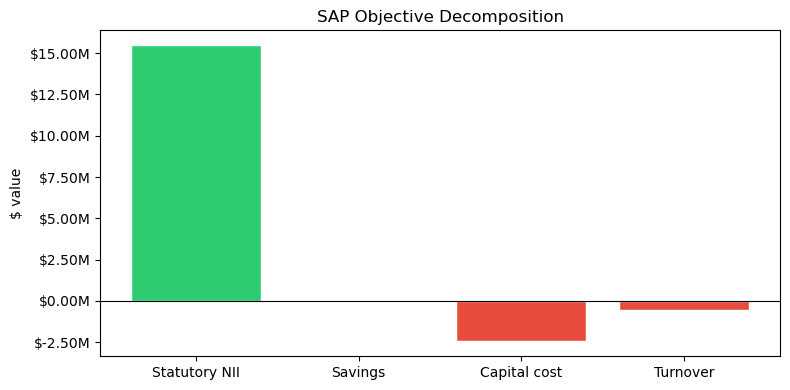

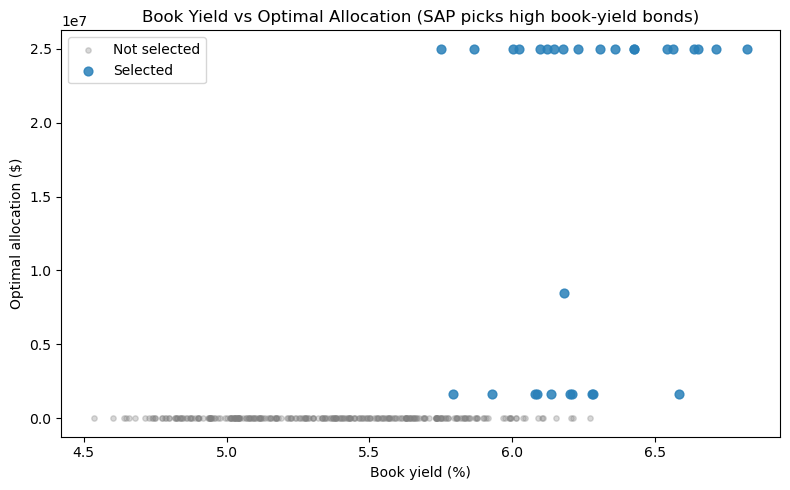

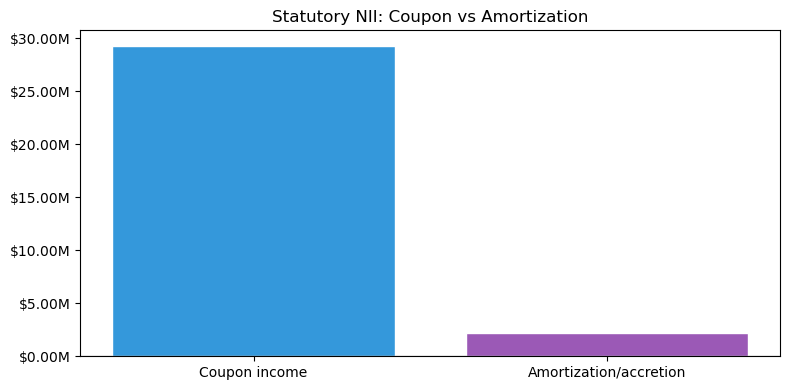

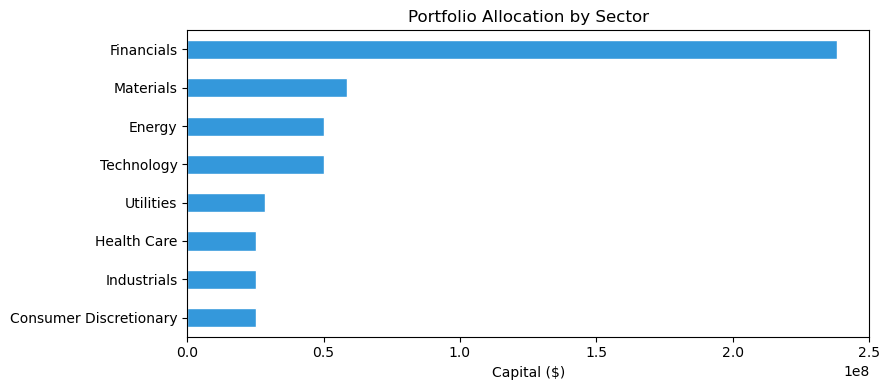

In [43]:
# -- 4D. Charts ---------------------------------------------------------------
# Fig 1: SAP objective decomposition
fig, ax = plt.subplots(figsize=(8, 4))
comp = [nii_val, savings_val, -capital_cost_val, -turnover_val]
lab  = ["Statutory NII", "Savings", "Capital cost", "Turnover"]
ax.bar(lab, comp, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in comp], edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("SAP Objective Decomposition"); ax.set_ylabel("$ value")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
plt.tight_layout(); plt.show()

# Fig 2: Book yield vs allocation (selected bonds)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(book_yield[~selected]*100, h_opt[~selected], alpha=0.3, color="grey", s=15, label="Not selected")
ax.scatter(book_yield[selected]*100,  h_opt[selected],  alpha=0.85, color="#2980b9", s=40, label="Selected")
ax.set_xlabel("Book yield (%)"); ax.set_ylabel("Optimal allocation ($)")
ax.set_title("Book Yield vs Optimal Allocation (SAP picks high book-yield bonds)")
ax.legend(); plt.tight_layout(); plt.show()

# Fig 3: Coupon vs amortization contribution of NII (selected bonds)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Coupon income", "Amortization/accretion"], [coupon_val, amort_val],
       color=["#3498db", "#9b59b6"], edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Statutory NII: Coupon vs Amortization")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
plt.tight_layout(); plt.show()

# Fig 4: Sector allocation
sector_alloc = {}
for i, c in enumerate(CUSIPS):
    s = str(fixed_df.loc[c, "sector"]); sector_alloc[s] = sector_alloc.get(s, 0.0) + h_opt[i]
ss = pd.Series(sector_alloc); ss = ss[ss > 0].sort_values()
fig, ax = plt.subplots(figsize=(9, max(4, len(ss)*0.4)))
ss.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Portfolio Allocation by Sector"); ax.set_xlabel("Capital ($)")
plt.tight_layout(); plt.show()

Sweeping cost_of_capital -- 20 LP solves ...
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Done.


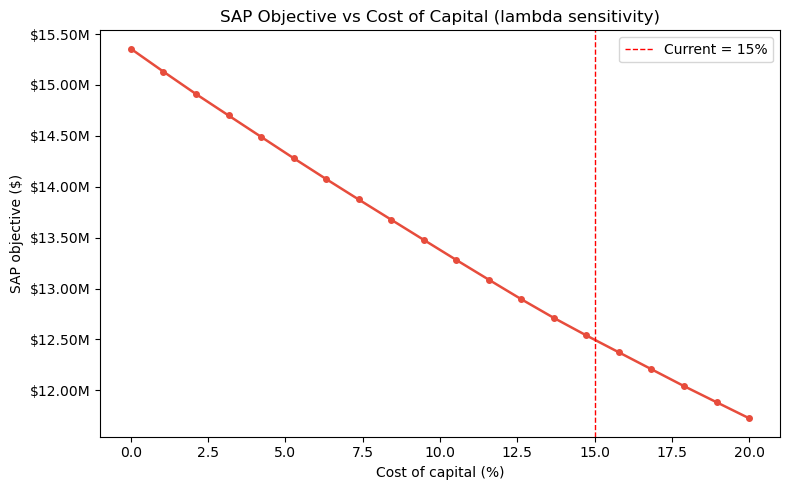

In [44]:
# -- 4E. Capital-cost sensitivity: SAP objective vs cost_of_capital -----------
# Re-solves the model for a sweep of cost_of_capital values; all else held fixed.
def _solve_sap(coc=cost_of_capital, eta_=eta, eps_D_=eps_D, delta_=delta):
    lam = coc * RBC_bar
    m = gp.Model("sap_sens"); m.Params.LogToConsole = 0; m.Params.OutputFlag = 0
    h2 = m.addVars(N, lb=0.0)
    # Step 2: post-FABN-maturity bonds admissible (no h2[i].ub=0 exclusion)
    dp = m.addVar(lb=0.0); dn = m.addVar(lb=0.0)
    tp = m.addVars(N, lb=0.0); tm = m.addVars(N, lb=0.0)
    B2 = m.addVars(Q, lb=0.0); sn = m.addVars(Q, lb=0.0)
    nii = gp.quicksum(nii_rate[i]*h2[i] for i in range(N))
    rbc = gp.quicksum(theta[i]*h2[i] for i in range(N))
    txn = gp.quicksum(tau[i]*(tp[i]+tm[i]) for i in range(N))
    sav = r_save * dt_q * gp.quicksum(B2[q] for q in range(Q-1))
    m.setObjective(nii - lam*rbc - txn + sav, GRB.MAXIMIZE)  # Step 1: no liq penalty (matches main model)
    m.addConstr(gp.quicksum(h2[i] for i in range(N)) == H)
    m.addConstr(gp.quicksum(durs[i]*h2[i] for i in range(N)) - D_FABN*H == dp - dn)
    m.addConstr(dp <= eps_D_*H); m.addConstr(dn <= eps_D_*H)
    for i in range(N):
        m.addConstr(h2[i] - h_curr[i] == tp[i] - tm[i])
    for iss, bidx in issuer_groups.items():
        m.addConstr(gp.quicksum(h2[i] for i in bidx) <= delta_*H)
    for q in range(Q):
        cfa = gp.quicksum(qtr_bond_cf[q, i]*h2[i] for i in range(N)); cfl = float(qtr_fabn_cf[q])
        if q == 0: m.addConstr(B2[q] - sn[q] == cfa - cfl)
        else:      m.addConstr(B2[q] - sn[q] == (1.0 + r_save*dt_q)*B2[q-1] + cfa - cfl)
    m.optimize()
    return m.ObjVal if m.Status == GRB.OPTIMAL else float("nan")

coc_range = np.linspace(0.0, 0.20, 20)
print("Sweeping cost_of_capital -- 20 LP solves ...")
sap_coc = [_solve_sap(coc=c) for c in coc_range]
print("Done.")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coc_range*100, sap_coc, "o-", color="#e74c3c", linewidth=1.8, markersize=4)
ax.axvline(cost_of_capital*100, color="red", linestyle="--", linewidth=1.0,
           label=f"Current = {cost_of_capital:.0%}")
ax.set_xlabel("Cost of capital (%)"); ax.set_ylabel("SAP objective ($)")
ax.set_title("SAP Objective vs Cost of Capital (lambda sensitivity)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
ax.legend(); plt.tight_layout(); plt.show()

  CVaR CALIBRATION SWEEP  (phi_cvar low = strict risk budget -> high = loose)
phi_cvar  budget $M feas  SAP $M  NII $M  D_eff  Swap $M  CVaR real $M CVaR governs?  issuer caps bind
   0.50%        2.5   ok  11.077  13.855  0.993    100.0          2.49           YES                18
   0.55%        2.8   ok  11.447  14.338  1.096    100.0          2.74           YES                19
   0.60%        3.0   ok  11.730  14.710  1.199    100.0          2.98           YES                18
   0.65%        3.2   ok  11.932  15.088  1.302    100.0          3.23           YES                17
   0.70%        3.5   ok  12.093  15.335  1.403    100.0          3.48           YES                19
   0.75%        3.8   ok  12.180  15.427  1.504    100.0          3.73           YES                18
   0.80%        4.0   ok  12.251  15.485  1.604    100.0          3.98           YES                19
   0.85%        4.2   ok  12.298  15.554  1.706    100.0          4.23           YES              

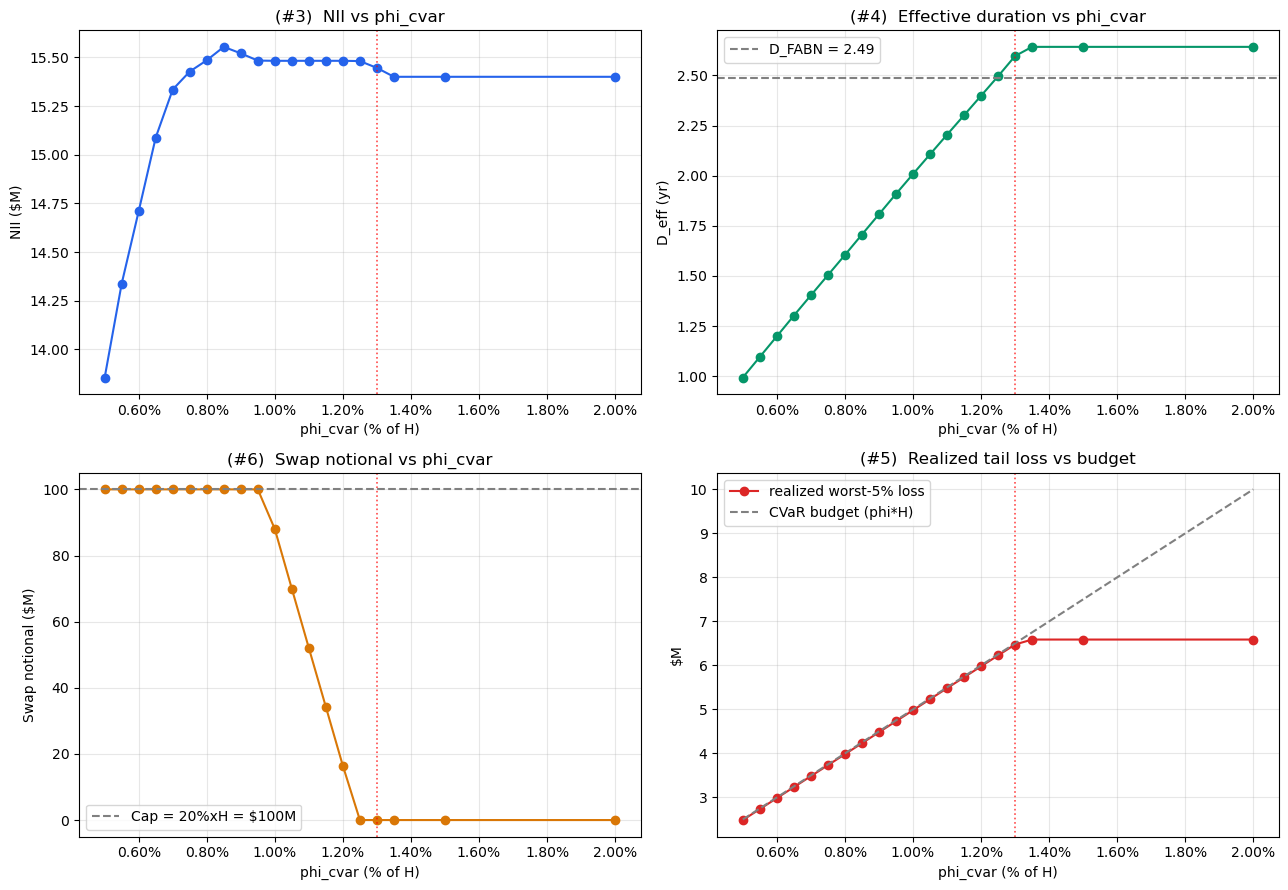

In [45]:
# =====================================================================
#  CVaR CALIBRATION SWEEP  --  leader points 3-6 in one shot
#  Re-solve on a COPY over a grid of phi_cvar; record how the portfolio
#  responds.  Non-destructive: the headline `model` solution is untouched.
# =====================================================================
if not use_cvar:
    print("use_cvar = False -- sweep skipped.")
else:
    _ms = model.copy(); _ms.Params.OutputFlag = 0
    _cl = _ms.getConstrByName("cvar_limit")
    _S  = cvar_relloss.shape[0]
    _nt = int(np.ceil((1.0 - cvar_alpha) * _S))          # worst-5% count
    _hs = use_swaps and K > 0
    _Dsw = np.asarray(D_swap) if _hs else np.zeros(0)
    _dr  = np.asarray(cvar_d_rate)

    def _cvar_real(h_o, v_o):
        loss = cvar_relloss @ h_o
        if _hs and v_o.sum() > 0:
            loss = loss + (_dr[:, None] * (_Dsw * v_o)[None, :]).sum(axis=1)
        return float(np.sort(loss)[-_nt:].mean())

    # Fine grid: all the action lives between the INFEAS floor (~0.35% of H) and
    # the free optimum (~1.32% of H).  Two loose points retained to show the plateau.
    phis = [round(p, 5) for p in (np.arange(50, 136, 5) / 10000.0)] + [0.015, 0.020]
    rec = []
    for p in phis:
        _cl.RHS = p * H
        _ms.optimize()
        if _ms.Status != GRB.OPTIMAL:
            rec.append(dict(phi=p, feasible=False, SAP=np.nan, NII=np.nan,
                            D_eff=np.nan, notional=np.nan, cvar_real=np.nan,
                            cvar_pi=np.nan, iss_bind=np.nan))
            continue
        h_o = np.array([_ms.getVarByName(f"h[{i}]").X for i in range(N)])
        v_o = np.array([_ms.getVarByName(f"v[{k}]").X for k in range(K)]) if _hs else np.zeros(0)
        d_eff = (float((durs * h_o).sum()) + (float((_Dsw * v_o).sum()) if _hs else 0.0)) / H
        rec.append(dict(
            phi=p, feasible=True, SAP=_ms.ObjVal,
            NII=float(sum(nii_rate[i] * h_o[i] for i in range(N))),
            D_eff=d_eff, notional=float(v_o.sum()) if _hs else 0.0,
            cvar_real=_cvar_real(h_o, v_o), cvar_pi=_cl.Pi,
            iss_bind=sum(1 for iss in issuer_groups
                         if abs(_ms.getConstrByName(f"conc_{iss}").Pi) > 1e-6)))
    sweep_df = pd.DataFrame(rec).sort_values("phi").reset_index(drop=True)
    sweep_df["CVaR governs?"] = np.where(sweep_df["cvar_pi"].abs() > 1e-6, "YES", "no")

    disp = pd.DataFrame({
        "phi_cvar"        : sweep_df.phi.map(lambda x: f"{x*100:.2f}%"),
        "budget $M"       : (sweep_df.phi * H / 1e6).round(1),
        "feas"            : np.where(sweep_df.feasible, "ok", "INFEAS"),
        "SAP $M"          : (sweep_df.SAP / 1e6).round(3),
        "NII $M"          : (sweep_df.NII / 1e6).round(3),
        "D_eff"           : sweep_df.D_eff.round(3),
        "Swap $M"         : (sweep_df.notional / 1e6).round(1),
        "CVaR real $M"    : (sweep_df.cvar_real / 1e6).round(2),
        "CVaR governs?"   : sweep_df["CVaR governs?"],
        "issuer caps bind": sweep_df.iss_bind,
    })
    print("=" * 78)
    print("  CVaR CALIBRATION SWEEP  (phi_cvar low = strict risk budget -> high = loose)")
    print("=" * 78)
    print(disp.to_string(index=False))
    _first = sweep_df.loc[sweep_df["CVaR governs?"] == "YES", "phi"]
    if len(_first):
        print(f"\n  -> CVaR starts GOVERNING at phi_cvar <= {_first.max()*100:.2f}%  "
              f"(${_first.max()*H/1e6:.1f}M budget).  Above that it is slack.")
    else:
        print("\n  -> CVaR never binds on this grid; some other constraint governs throughout.")

    _f = sweep_df[sweep_df.feasible]
    x  = _f.phi * 100
    fig, ax = plt.subplots(2, 2, figsize=(13, 9))
    ax[0,0].plot(x, _f.NII/1e6, "o-", color="#2563eb")
    ax[0,0].set_title("(#3)  NII vs phi_cvar"); ax[0,0].set_ylabel("NII ($M)")
    ax[0,1].plot(x, _f.D_eff, "o-", color="#059669")
    ax[0,1].axhline(D_FABN, ls="--", c="grey", label=f"D_FABN = {D_FABN:.2f}")
    ax[0,1].set_title("(#4)  Effective duration vs phi_cvar"); ax[0,1].set_ylabel("D_eff (yr)"); ax[0,1].legend()
    ax[1,0].plot(x, _f.notional/1e6, "o-", color="#d97706")
    if _hs:
        ax[1,0].axhline(swap_cap_pct*H/1e6, ls="--", c="grey",
                        label=f"Cap = {swap_cap_pct:.0%}xH = ${swap_cap_pct*H/1e6:.0f}M")
        ax[1,0].legend()
    ax[1,0].set_title("(#6)  Swap notional vs phi_cvar"); ax[1,0].set_ylabel("Swap notional ($M)")
    ax[1,1].plot(x, _f.cvar_real/1e6, "o-", label="realized worst-5% loss", color="#dc2626")
    ax[1,1].plot(x, _f.phi*H/1e6, "--", label="CVaR budget (phi*H)", color="grey")
    ax[1,1].set_title("(#5)  Realized tail loss vs budget"); ax[1,1].set_ylabel("$M"); ax[1,1].legend()
    for a in ax.ravel():
        a.set_xlabel("phi_cvar (% of H)")
        a.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}%"))
        a.grid(alpha=0.3)
        if len(_first):                      # red dotted = CVaR stops governing here
            a.axvline(_first.max()*100, color="red", ls=":", lw=1.2, alpha=0.7)
    plt.tight_layout(); plt.show()
